<div style="border-radius:14px; border: 2px solid #6c63ff; padding: 30px 36px; font-family: Georgia, serif; background: #fafafa;">

<div style="display:flex; align-items:center; gap:24px; margin-bottom:20px;">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/5e/Escudo_de_la_Pontificia_Universidad_Javeriana.svg/200px-Escudo_de_la_Pontificia_Universidad_Javeriana.svg.png" width="88" style="border-radius:8px;" />
  <div>
    <div style="font-size:1.5em; font-weight:700; color:#00205B; letter-spacing:0.5px;">Pontificia Universidad Javeriana</div>
    <div style="font-size:1em; color:#555; font-style:italic; margin-top:4px;">Bogotá, Colombia — Facultad de Ingeniería</div>
  </div>
</div>

<hr style="border:none; border-top:2px solid #6c63ff; margin:16px 0;" />

<div style="font-size:1.45em; font-weight:700; color:#1a1a2e; margin-bottom:16px; text-align:center;">
  📊 Clasificación y Métricas de Aprendizaje en Dataset de Banca
</div>

<table style="width:100%; border-collapse:collapse; font-size:1em;">
  <tr style="background:#f0eeff;">
    <td style="padding:8px 14px; font-weight:600; color:#6c63ff; width:140px;">📘 Materia</td>
    <td style="padding:8px 14px; color:#222;">Procesamiento de Datos a Gran Escala</td>
  </tr>
  <tr>
    <td style="padding:8px 14px; font-weight:600; color:#6c63ff;">✍️ Autor</td>
    <td style="padding:8px 14px; color:#222;">Samuel Clavijo</td>
  </tr>
  <tr style="background:#f0eeff;">
    <td style="padding:8px 14px; font-weight:600; color:#6c63ff;">📅 Fecha</td>
    <td style="padding:8px 14px; color:#222;">16 de marzo de 2026</td>
  </tr>
  <tr>
    <td style="padding:8px 14px; font-weight:600; color:#6c63ff;">🎯 Objetivo</td>
    <td style="padding:8px 14px; color:#222;">Analizar el rendimiento de modelos de clasificación sobre un dataset de marketing bancario portugués, evaluando Accuracy, Precision, Recall, F1-Score y curva ROC.</td>
  </tr>
</table>

<hr style="border:none; border-top:1px solid #ddd; margin:16px 0;" />

<div style="font-size:0.92em; color:#555; background:#f9f9ff; border-radius:8px; padding:12px 16px;">
  <strong>📂 Dataset:</strong> <em>Bank Marketing Dataset</em> — UCI Machine Learning Repository. Contiene 45.211 registros de campañas de marketing directo de un banco portugués. El objetivo es predecir si un cliente suscribirá un depósito a plazo (<code>y = yes/no</code>).
</div>

</div>


In [ ]:
!pip install pyspark

In [ ]:
!pip install pandas

In [ ]:
!pip install seaborn

In [ ]:
!pip install scikit-learn


In [ ]:
## Se instala la biblioteca FindSpark
!pip install tensorflow

In [3]:
### Importar bibliotecas de uso General 
import os
import sys

import numpy as np          #- - -> Para graficar y objetos dataframe
import pandas as pd         #- - -> Para algebra matricial
import seaborn as sns       #- - -> Para formatos de graficas
import matplotlib.pyplot as plt           #- - -> Para crear, personalizar y visualizar gráficos 2D de forma sencilla

In [4]:
### Importar bibliotecas de usos especificos

## Importacion de la funcion para pyspark
import findspark
findspark.init()

from pyspark.sql import functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession
from pyspark.sql import SQLContext

---
### 🧩 Entorno de Trabajo y Bibliotecas

> **¿Qué es PySpark?** Apache Spark es un motor de procesamiento distribuido para grandes volúmenes de datos. PySpark es su interfaz en Python, que permite aplicar transformaciones, ML y SQL sobre clústeres de máquinas.

| Biblioteca | Rol en el proyecto |
|---|---|
| `pyspark` | Motor de procesamiento distribuido y ML |
| `pandas` | Manipulación de datos en memoria local |
| `seaborn` | Visualizaciones estadísticas elegantes |
| `matplotlib` | Gráficas 2D personalizables |
| `scikit-learn` | Métricas complementarias (curva ROC) |
| `findspark` | Localiza la instalación de Spark en el sistema |

---



**Diagnostico y tratamiento de datos sobre Pyspark**
*1.* Cambio de nombres de columnas
*2.* Tipos y coherencia de datos
*3.* Identificacion y tratamiento de datos nulos
*4.* Estadisticas generales
*5.* Categorias y cambios sobre el tipo de datos de las categorias.

In [5]:
## Se requiere levantar la sesion para trabajar en los servicios
## BAsados en Spark: Procesamiento paralelo y distribuido sobre grandes volumenes de datos
configura = SparkConf()#- - ->No requiere configuracion
configura.set("spark.scheduler.mode","FAIR")
configura.set("spark.scheduler.allocation","/Almacen/Spark/conf/fairscheduler.xml")
configura.setMaster("spark://10.43.97.177:7077")
configura.setAppName("Taller_Banca_Metricas_Clavijo")
## Se crea el contexto de Procesamiento
sparkClavijo = SparkSession.builder.config(conf=configura).getOrCreate()

sparkClavijo

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 22:18:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


---
### ⚡ Sesión de Spark

> **SparkSession** es el punto de entrada unificado para trabajar con Spark desde Python. Gestiona el contexto de ejecución distribuida, la configuración del clúster y el acceso a las APIs de SQL y ML.

**Configuración relevante de esta sesión:**
- `spark.scheduler.mode = FAIR` → Distribuye recursos de forma equitativa entre múltiples jobs.
- `setMaster("spark://...")` → Conecta al clúster Spark en modo standalone (no local).
- `setAppName(...)` → Nombre con el que aparece el job en la UI de Spark.

---


In [ ]:

## Se requiere revisar los ficheros cargados en el HADOOP HDFS
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv/stro*

In [ ]:
!pwd

In [6]:
###Se carga el STROKE>CSV desde HADOOP HDFS a la sesion de 
###Pyspark actual

##el 9000 es para almacenamiento
df00 = sparkClavijo.read.format("csv").option("header","true").option("sep",";").load("file:///Almacen/bank-full.csv")
df00.show(5)

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

In [5]:
df00.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

---
### 📂 Carga de Datos desde HDFS

> **HDFS (Hadoop Distributed File System)** es un sistema de archivos distribuido que permite almacenar grandes volúmenes de datos repartidos en múltiples nodos. Spark lo usa nativamente como fuente de datos.

El archivo `bank-full.csv` contiene **45.211 registros** con **17 variables** relacionadas con campañas de marketing bancario. Se carga usando:
- `format("csv")` → formato de lectura
- `option("header", "true")` → la primera fila contiene nombres de columnas
- `option("sep", ";")` → separador punto y coma (formato europeo)

---


#### Descripción de Variables del Dataset

A continuación se presenta la descripción de cada variable del dataset bancario:

| Variable | Rol | Tipo | Demográfico | Descripción | Unidades | Valores Faltantes |
|----------|-----|------|-------------|-------------|----------|-------------------|
| age | Feature | Integer | Edad | Edad del cliente | — | No |
| job | Feature | Categorical | Ocupación | Tipo de trabajo (admin., obrero, emprendedor, empleada del hogar, gerencia, jubilado, autónomo, servicios, estudiante, técnico, desempleado, desconocido) | — | No |
| marital | Feature | Categorical | Estado civil | Estado civil (divorciado, casado, soltero, desconocido; 'divorciado' incluye viudos) | — | No |
| education | Feature | Categorical | Nivel educativo | Nivel de educación (básica 4 años, básica 6 años, básica 9 años, bachillerato, analfabeto, curso profesional, título universitario, desconocido) | — | No |
| default | Feature | Binary | — | ¿Tiene crédito en mora? | — | No |
| balance | Feature | Integer | — | Saldo anual promedio | Euros | No |
| housing | Feature | Binary | — | ¿Tiene préstamo hipotecario? | — | No |
| loan | Feature | Binary | — | ¿Tiene préstamo personal? | — | No |
| contact | Feature | Categorical | — | Tipo de comunicación de contacto (celular, teléfono) | — | Sí |
| day_of_week | Feature | Date | — | Último día de contacto de la semana | — | No |
| month | Feature | Date | — | Último mes de contacto del año (ene, feb, mar, ..., nov, dic) | — | No |
| duration | Feature | Integer | — | Duración del último contacto en segundos. Nota importante: este atributo afecta significativamente el resultado (si duration=0 entonces y='no'). Sin embargo, la duración no se conoce antes de realizar la llamada, por lo que debe usarse solo para referencia y descartarse en modelos predictivos realistas. | — | No |
| campaign | Feature | Integer | — | Número de contactos realizados durante esta campaña para este cliente (incluye el último contacto) | — | No |
| pdays | Feature | Integer | — | Días transcurridos desde que el cliente fue contactado por última vez en una campaña anterior (-1 significa que no fue contactado previamente) | — | Sí |
| previous | Feature | Integer | — | Número de contactos realizados antes de esta campaña para este cliente | — | No |
| poutcome | Feature | Categorical | — | Resultado de la campaña de marketing anterior (fracaso, inexistente, éxito) | — | Sí |
| y | Target | Binary | — | ¿El cliente suscribió un depósito a plazo? | — | No |


In [6]:
#### Revision de tipos de datos
df00.printSchema()

root
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



---
### 🔍 Diagnóstico del Esquema de Datos

> **`printSchema()`** en PySpark muestra el árbol de tipos de datos de cada columna. Es el primer paso del diagnóstico: permite identificar qué variables llegaron como `StringType` (texto) cuando debían ser numéricas.

**Tipos esperados en este dataset:**
- `IntegerType` → `age`, `balance`, `duration`, `campaign`, `pdays`, `previous`, `day`
- `StringType` → `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`, `y`

Si Spark infiere todos los campos como `String` (comportamiento por defecto en CSV), es necesario hacer **casting explícito** antes de cualquier análisis numérico.

---


- Se observa que las variables numéricas (`age`, `balance`, `duration`, `campaign`, `pdays`, `previous`) están correctamente tipificadas como enteros (`IntegerType`).
- Las variables categóricas como `job`, `marital`, `education`, `contact`, `month`, `poutcome` y la variable objetivo `y` permanecen como `StringType`, lo cual es esperado antes del proceso de codificación.
- El esquema refleja una estructura mixta (numérica y categórica) propia de datasets de marketing bancario.
- Es necesario aplicar técnicas de codificación (`StringIndexer`, `OneHotEncoder`) a las variables categóricas antes de entrenar modelos de clasificación.

In [19]:
## Cambiar las variables correspondientes a dato de tipo entero

nombreColumnas = ['age','job','marital',
                  'education','default','balance',
                  'housing','loan','contact',
                  'day','month','duration',
                  'campaign','pdays','previous',
                  'poutcome','y']

columnas_int = ['age','balance','duration',
                  'campaign','pdays','previous', 'day']

#Se hace el casting a entero
df01 = df00.withColumn("age",df00.age.cast("int"))
df01 = df01.withColumn("balance",df00.balance.cast("int"))
df01 = df01.withColumn("duration",df00.duration.cast("int"))
df01 = df01.withColumn("campaign",df00.campaign.cast("int"))
df01 = df01.withColumn("pdays",df00.pdays.cast("int"))
df01 = df01.withColumn("previous",df00.previous.cast("int"))
df01 = df01.withColumn("day",df00.day.cast("int"))

#Se verifica el cambio de dato
df01.printSchema()


root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



In [8]:
## Se observa las 10 primeras filas del objeto dataframe SPark

df01.show(10)

[Stage 2:>                                                          (0 + 1) / 1]

+---+------------+--------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job| marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+--------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management| married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician|  single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur| married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar| married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown|  single|  unknown|     no|      1|     no|  no|unknown|  5|  may

---
### 🔄 Conversión de Tipos (Casting)

> **Casting** es el proceso de convertir el tipo de dato de una columna a otro más apropiado. En Spark se hace con `.cast("int")`, `.cast("double")`, etc.

Se convirtieron a entero las variables: `age`, `balance`, `duration`, `campaign`, `pdays`, `previous` y `day`. Esto es necesario para:
1. Calcular estadísticas descriptivas correctas
2. Alimentar el `VectorAssembler` más adelante (que solo acepta tipos numéricos)
3. Graficar histogramas y boxplots con valores continuos

---


- Se observa que la variable dependiente `y` es de tipo binario: indica si el cliente suscribió o no un depósito a plazo.
- Lo anterior representa un posible desbalance de la variable dependiente.
- Se recomienda cuantificar el balanceo de la variable binaria antes de proceder con el modelado.

In [20]:
##Balanceo de la variable y
cantTotal = df00.count()
cantY = df00.groupBy("y").count()


print(f"Cantidad total de registros del dataset = {cantTotal} sin exhaustivo EDA\n")

#Tabla para presentar el porcentaje de la variable binaria Y (Variable Dependiente)
dfAUX = cantY.withColumn("Porcentaje", cantY["count"]*100/cantTotal)

dfAUX.toPandas()

Cantidad total de registros del dataset = 45211 sin exhaustivo EDA



,y,count,Porcentaje
0,no,39922,88.30152
1,yes,5289,11.69848


---
### ⚖️ Balanceo de la Variable Objetivo

> **Desbalance de clases** ocurre cuando una categoría de la variable objetivo es significativamente más frecuente que otra. En clasificación binaria, esto puede hacer que el modelo simplemente aprenda a predecir siempre la clase mayoritaria.

**Ejemplo de impacto:** Si el 88% de los datos es `no`, un modelo que siempre predice `no` tendría 88% de accuracy **sin aprender nada útil**. Por eso el accuracy solo no es suficiente métrica.

---


- La tabla muestra un claro desbalance en la variable objetivo `y`: aproximadamente el **88.3%** de los clientes respondió `no` a la suscripción del depósito, mientras que solo el **11.7%** respondió `yes`.
- Este desbalance es crítico para el entrenamiento de modelos de clasificación, ya que un modelo que siempre prediga `no` alcanzaría una precisión aparente del 88%, sin ser realmente útil.
- Se recomienda aplicar técnicas de balanceo como SMOTE, submuestreo aleatorio o ajuste de pesos de clase antes de entrenar los modelos.

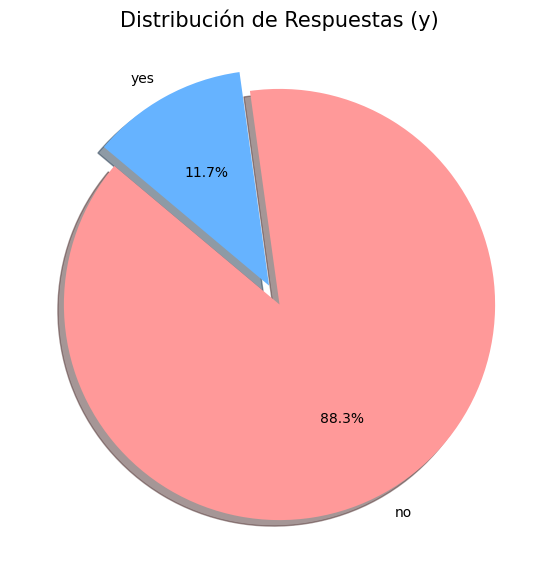

In [11]:
##Graficacion 
# Datos extraídos de tu tabla
labels = ['no', 'yes']
sizes = [39922, 5289]
colores = ['#ff9999','#66b3ff'] # Colores suaves
explode = (0, 0.1)  # Separa un poco la rebanada de 'yes'

plt.figure(figsize=(7, 7))

# Se crea el gráfico
plt.pie(sizes, 
        explode=explode, 
        labels=labels, 
        colors=colores, 
        autopct='%1.1f%%', # Formato de los porcentajes
        shadow=True, 
        startangle=140) # Girar el gráfico para que se vea mejor

plt.title('Distribución de Respuestas (y)', fontsize=15)


plt.show()

- Lo más evidente en el gráfico es que una gran cantidad de personas **no ha suscrito** un depósito a plazo, siendo un total del 88.3% contra el 11.7% que sí están suscritos.
- Esto indica que la estrategia del banco con respecto a la búsqueda de clientes es muy amplia pero con poca eficiencia en la conversión.
- La alta proporción de respuestas negativas resalta la necesidad de un análisis más profundo para identificar el perfil del cliente que sí convierte.

In [16]:
## Estudio y análisis sobre las variables numericas
df01.describe().toPandas().head()

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975408,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044596,None,257.52781226517095,3.098020883279184,100.12874599059813,2.3034410449312204,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,9,sep,4918,63,871,275,unknown,yes


- Las estadísticas descriptivas revelan que la variable `balance` presenta una alta variabilidad (desviación estándar elevada), lo que sugiere presencia de valores atípicos (*outliers*).
- La variable `duration` tiene una media considerablemente superior a su mediana, indicando una distribución sesgada a la derecha: existen algunas llamadas de larga duración que elevan el promedio.
- La variable `pdays` muestra un valor mínimo de -1, que representa clientes no contactados previamente; este valor especial debe ser tratado (binarización o imputación) antes del modelado.
- Variables como `campaign` y `previous` presentan medias bajas pero valores máximos muy altos, lo que también apunta a presencia de valores atípicos.

---
### 📐 Estadísticas Descriptivas

> **`describe()`** en PySpark calcula para cada columna numérica: `count`, `mean`, `stddev`, `min` y `max`. Es el primer vistazo a la distribución de los datos.

**Conceptos clave:**
- **Media (mean):** promedio aritmético; sensible a outliers.
- **Desviación estándar (stddev):** mide la dispersión; alta stddev = datos muy dispersos.
- **Rango (min-max):** indica la amplitud de los valores; extremos pueden ser outliers.

---


NameError: name 'age' is not defined

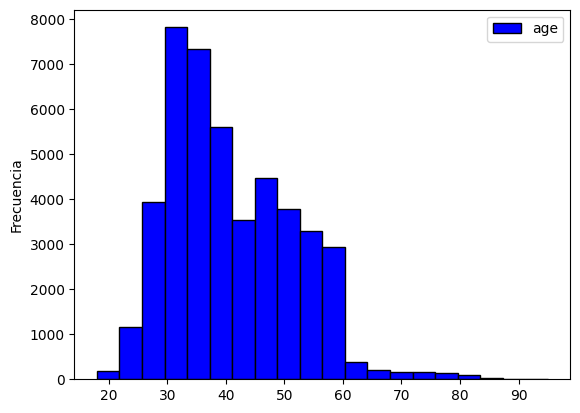

In [17]:
histGra = df01.select("age").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='blue')
plt.ylabel("Frecuencia")
plt.xlabel(age.capitalize())
plt.title(f"{age.capitalize()} frecuency")
plt.grid()
plt.show()

---
### 📊 Análisis de Distribución — Histogramas

> Un **histograma** divide el rango de valores en intervalos (bins) y cuenta cuántos registros caen en cada uno. Permite detectar la forma de la distribución: normal, sesgada, bimodal, etc.

**Patrones a buscar:**
- 🔔 **Distribución normal (campana):** simétrica, media ≈ mediana
- ➡️ **Sesgo positivo (cola derecha):** la mayoría de datos están a la izquierda; hay valores muy altos
- ⬅️ **Sesgo negativo (cola izquierda):** la mayoría están a la derecha; hay valores muy bajos
- 🏔️ **Bimodal:** dos picos, puede indicar dos subpoblaciones

---


- El histograma de edad muestra una distribución aproximadamente normal con leve sesgo hacia edades medias (30–50 años).
- La mayor concentración de clientes se encuentra entre los **30 y 40 años**, lo cual es representativo de una población laboralmente activa.
- Hay una presencia menor pero notable de clientes mayores de 60 años (posiblemente jubilados), quienes históricamente muestran mayor interés en depósitos a plazo.

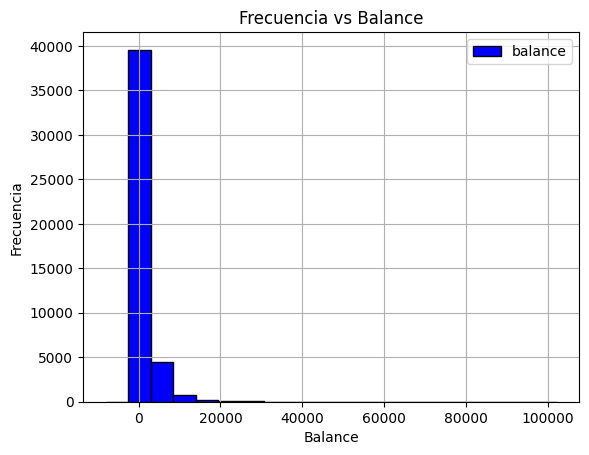

In [20]:
histGra = df01.select("balance").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='blue')
plt.ylabel("Frecuencia")
plt.xlabel("Balance")
plt.title("Frecuencia vs Balance")
plt.grid()
plt.show()

- El histograma de saldo (`balance`) presenta una distribución muy concentrada cerca de cero, con una cola derecha extensa que indica la presencia de clientes con saldos muy altos (*outliers* positivos).
- La mayoría de los clientes tienen saldos anuales modestos o bajos, lo que es consistente con una base de datos de marketing masivo.
- Los valores extremos pueden afectar el rendimiento de ciertos modelos sensibles a la escala, por lo que se recomienda aplicar normalización o escalado de características.

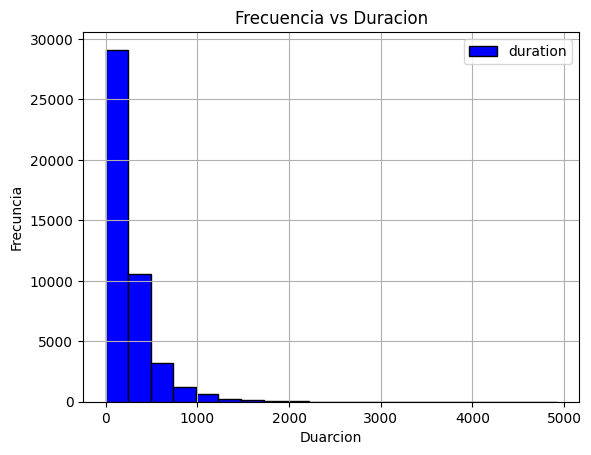

In [24]:
histGra = df01.select("duration").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='blue')
plt.ylabel("Frecuncia")
plt.xlabel("Duarcion")
plt.title("Frecuencia vs Duracion")
plt.grid()
plt.show()

- La distribución de la duración de las llamadas está fuertemente sesgada hacia la derecha: la mayoría de las llamadas son cortas (menos de 200 segundos), pero existe una cola de llamadas muy largas.
- Las llamadas más largas están asociadas con mayor probabilidad de suscripción (`y='yes'`), lo que hace de esta variable un predictor poderoso pero que debe usarse con cautela en producción, ya que no se conoce antes de realizar la llamada.

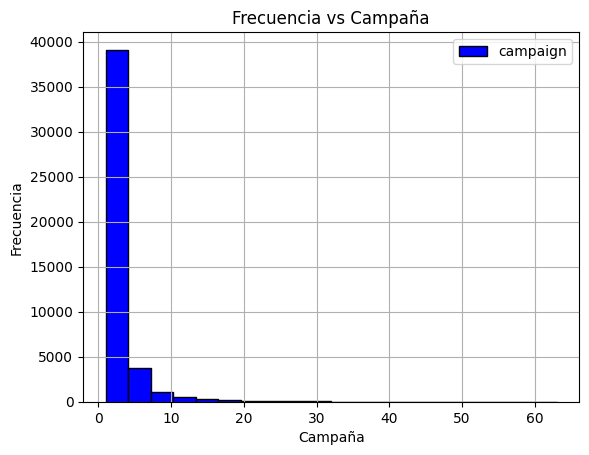

In [23]:
histGra = df01.select("campaign").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='blue')
plt.ylabel("Frecuencia")
plt.xlabel("Campaña")
plt.title("Frecuencia vs Campaña")
plt.grid()
plt.show()

- El histograma de `campaign` muestra que la gran mayoría de los clientes fue contactado entre **1 y 3 veces** durante la campaña.
- Existe una cantidad muy reducida de clientes con muchos contactos (más de 10), lo que sugiere que el esfuerzo de recontacto masivo no es una práctica frecuente.
- Un mayor número de contactos no necesariamente se traduce en mayor probabilidad de suscripción; al contrario, puede generar rechazo.

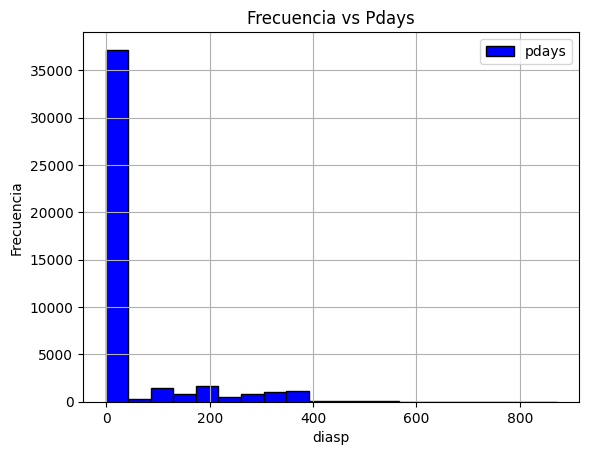

In [25]:
histGra = df01.select("pdays").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='blue')
plt.ylabel("Frecuencia")
plt.xlabel("diasp")
plt.title("Frecuencia vs Pdays")
plt.grid()
plt.show()

- El histograma de `pdays` muestra que la abrumadora mayoría de los registros tiene valor **-1**, indicando que esos clientes no fueron contactados en campañas anteriores.
- Solo una fracción pequeña tiene valores positivos, lo que significa que pocos clientes tienen historial de contacto previo.
- Esta variable requiere un tratamiento especial: se recomienda crear una variable binaria (*fue_contactado_antes*: sí/no) para capturar mejor su significado.

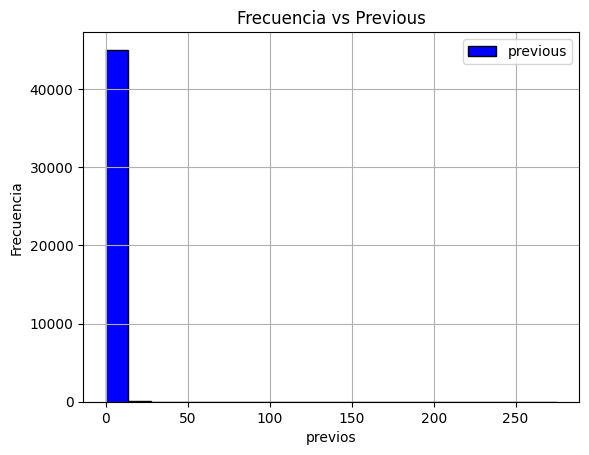

In [26]:
histGra = df01.select("previous").toPandas()
histGra.plot(kind='hist', bins=20, edgecolor='black', color='blue')
plt.ylabel("Frecuencia")
plt.xlabel("previos")
plt.title("Frecuencia vs Previous")
plt.grid()
plt.show()

- Al igual que `pdays`, la variable `previous` (número de contactos antes de esta campaña) está muy concentrada en **cero**.
- La mayoría de los clientes no tenía contactos previos, lo que refuerza que el dataset corresponde en su mayoría a clientes nuevos para la campaña.
- Los pocos clientes con contactos previos pueden representar un segmento más cálido y propenso a la conversión.

NameError: name 'age' is not defined

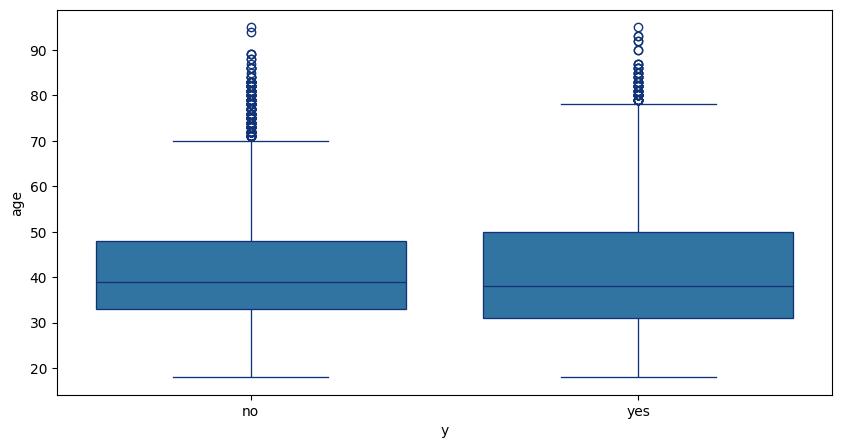

In [17]:
plt.figure(figsize=(10,5))
sns.boxplot(x='y', y='age', linecolor="#137", linewidth=0.95, data=df01.toPandas())
plt.title(f"{age.capitalize()} vs Si o NO al deposito")
plt.xlabel("Deposit")
plt.ylabel(age.capitalize())
plt.grid()
plt.show()

---
### 📦 Análisis Bivariado — Boxplots vs Variable Objetivo

> Un **boxplot** (diagrama de caja y bigotes) muestra la distribución de una variable numérica en cinco resúmenes: mínimo, Q1 (25%), mediana (50%), Q3 (75%) y máximo. Los puntos fuera de los bigotes son **outliers**.

En este análisis se compara cada variable numérica **separada por la variable `y`** (sí/no suscribió), buscando diferencias significativas en la distribución entre ambos grupos. Si los boxplots son claramente diferentes, la variable tiene poder predictivo.

```
[ Q1 |  Mediana  | Q3 ]  ←── caja (50% central de los datos)
   |←── bigote ──→|      ←── 1.5 × IQR
   •                     ←── outlier
```

---


- El boxplot muestra que los clientes que suscribieron el depósito (`yes`) tienden a ser **ligeramente mayores** en edad en comparación con los que no suscribieron.
- La mediana de edad del grupo `yes` es levemente superior, lo que sugiere que los clientes de mayor edad son más propensos a interesarse en productos de ahorro.
- Ambos grupos presentan valores atípicos en edades avanzadas, pero en general la distribución es similar, indicando que la edad por sí sola no es un factor determinante.

NameError: name 'balance' is not defined

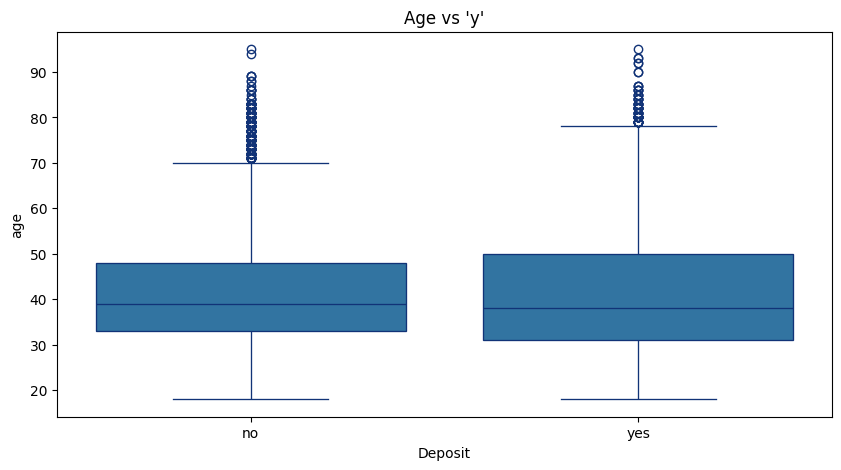

In [27]:
plt.figure(figsize=(10,5))
sns.boxplot(x='y', y='age', linecolor="#137", linewidth=0.95, data=df01.toPandas())
plt.title("Age vs 'y'")
plt.xlabel("Deposit")
plt.ylabel(balance.capitalize())
plt.grid()
plt.show()

NameError: name 'balance' is not defined

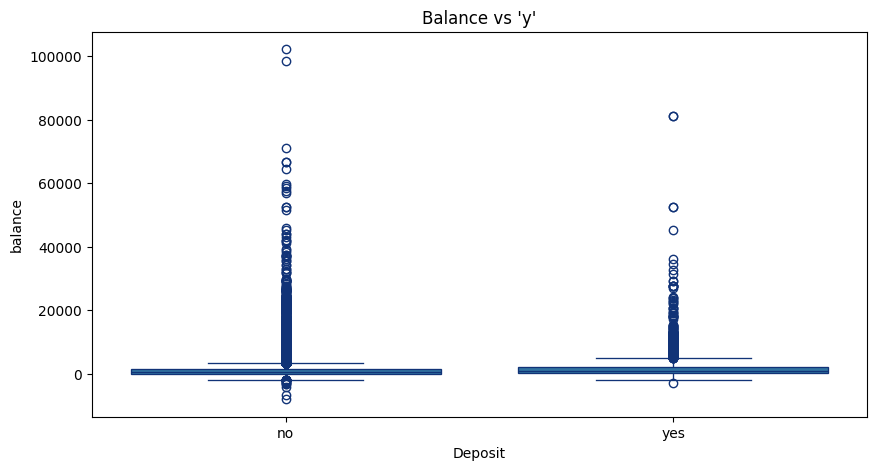

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(x='y', y='balance', linecolor="#137", linewidth=0.95, data=df01.toPandas())
plt.title("Balance vs 'y'")
plt.xlabel("Deposit")
plt.ylabel(balance.capitalize())
plt.grid()
plt.show()

- Los clientes que suscribieron el depósito (`yes`) presentan en promedio un **saldo bancario más alto** que los que no suscribieron.
- Esto sugiere que el nivel económico del cliente (medido por el saldo) tiene correlación positiva con la decisión de suscripción.
- Ambos grupos presentan numerosos *outliers* con saldos muy altos, lo que confirma la alta variabilidad observada en las estadísticas descriptivas.

NameError: name 'campaign' is not defined

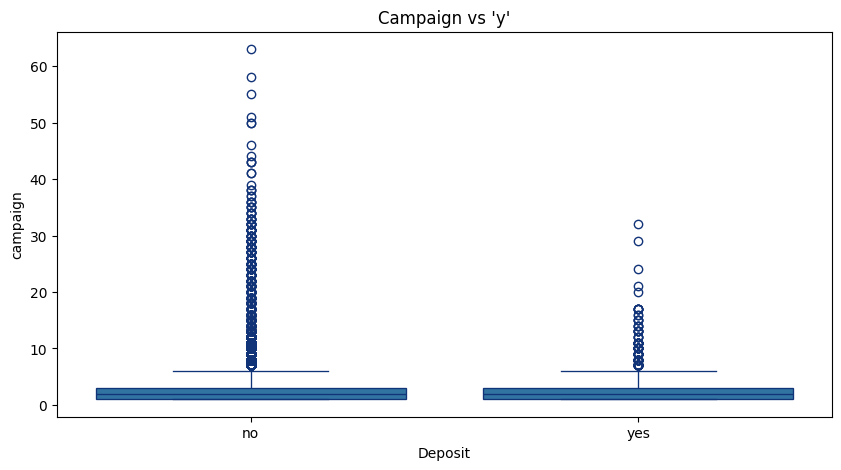

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(x='y', y='campaign', linecolor="#137", linewidth=0.95, data=df01.toPandas())
plt.title("Campaign vs 'y'")
plt.xlabel("Deposit")
plt.ylabel(campaign.capitalize())
plt.grid()
plt.show()

- El boxplot de `campaign` muestra que no existe una diferencia clara entre los grupos `yes` y `no` en cuanto al número de contactos realizados durante la campaña.
- Ambos grupos tienen medianas similares y bajas (alrededor de 2 contactos), lo que indica que el número de llamadas no es un predictor fuerte de la suscripción.
- El grupo `no` presenta más *outliers* con alto número de contactos, lo que podría indicar que insistir demasiado no mejora la conversión.

NameError: name 'pdays' is not defined

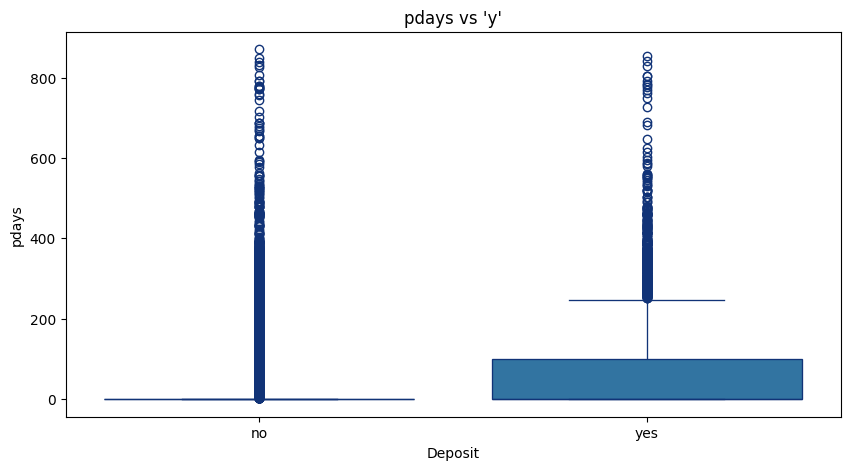

In [30]:
plt.figure(figsize=(10,5))
sns.boxplot(x='y', y='pdays', linecolor="#137", linewidth=0.95, data=df01.toPandas())
plt.title("pdays vs 'y'")
plt.xlabel("Deposit")
plt.ylabel(pdays.capitalize())
plt.grid()
plt.show()

- El boxplot de `pdays` es difícil de interpretar visualmente debido a la alta concentración de valores en **-1** (sin contacto previo).
- Sin embargo, los clientes con contactos previos (`pdays > 0`) que suscribieron tienden a tener un intervalo de días más corto desde el último contacto, sugiriendo que el seguimiento oportuno mejora la conversión.
- Se recomienda transformar esta variable antes del modelado para extraer mejor su información.

NameError: name 'previous' is not defined

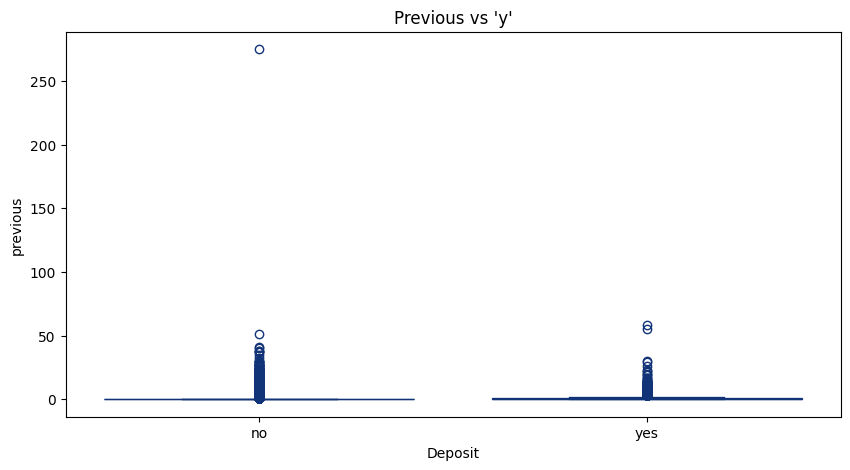

In [31]:
plt.figure(figsize=(10,5))
sns.boxplot(x='y', y='previous', linecolor="#137", linewidth=0.95, data=df01.toPandas())
plt.title("Previous vs 'y'")
plt.xlabel("Deposit")
plt.ylabel(previous.capitalize())
plt.grid()
plt.show()

- El boxplot de `previous` refleja que la mayoría de los clientes tiene **cero contactos previos**, lo cual genera una distribución muy concentrada en el extremo inferior.
- Los clientes con al menos un contacto previo que suscribieron (`yes`) tienden a mostrar una mediana de `previous` ligeramente más alta, lo que sugiere que el historial de interacción previo tiene valor predictivo.
- La presencia de outliers con muchos contactos previos es escasa, y no se asocia necesariamente con mayor conversión.


In [32]:
colNum = ['age','balance','duration','campaign','pdays','previous']
dfauxNum = df01.select(colNum + ['y'])
dfauxNum = dfauxNum.withColumn('y',F.when(dfauxNum['y'] =='yes',1).otherwise(0))
dfauxNum.show(5)

+---+-------+--------+--------+-----+--------+---+
|age|balance|duration|campaign|pdays|previous|  y|
+---+-------+--------+--------+-----+--------+---+
| 58|   2143|     261|       1|   -1|       0|  0|
| 44|     29|     151|       1|   -1|       0|  0|
| 33|      2|      76|       1|   -1|       0|  0|
| 47|   1506|      92|       1|   -1|       0|  0|
| 33|      1|     198|       1|   -1|       0|  0|
+---+-------+--------+--------+-----+--------+---+
only showing top 5 rows



- Se ha creado un subconjunto de datos con las variables numéricas y la variable objetivo `y`, transformando esta última a formato binario (`0 = no`, `1 = yes`).
- Esta transformación es necesaria para calcular la matriz de correlación y para el posterior entrenamiento de modelos de clasificación.
- Las primeras 5 filas confirman que los valores se han codificado correctamente.

---
### 🔗 Análisis de Correlación

> La **correlación de Pearson** mide la relación lineal entre dos variables numéricas. Va de -1 a +1:
> - **+1:** relación positiva perfecta
> - **0:** sin relación lineal
> - **-1:** relación negativa perfecta

En PySpark se usa `pyspark.ml.stat.Correlation` sobre un vector ensamblado. Primero se transforma el DataFrame en un vector de features con `VectorAssembler`, y luego se calcula la matriz de correlación sobre ese vector.

**¿Por qué importa?**
- Variables muy correlacionadas entre sí → **multicolinealidad** → puede afectar la regresión logística
- Variables correlacionadas con `y` → potenciales **buenos predictores**

---


In [33]:
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.stat import Correlation
ensamblador = VectorAssembler(inputCols=dfauxNum.columns, outputCol='features')
dfNumVector = ensamblador.transform(dfauxNum).select('features')

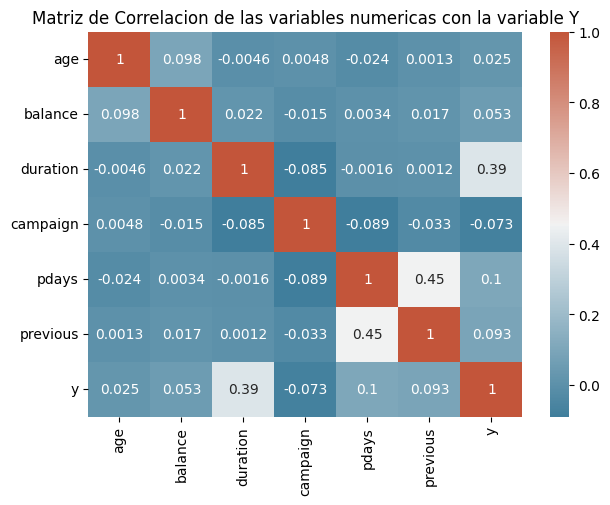

In [34]:
matrizCorr = Correlation.corr(dfNumVector,'features').head()

vectorCorr = matrizCorr[0].toArray()

dfCorrelatio= pd.DataFrame(vectorCorr, columns= dfauxNum.columns, index= dfauxNum.columns)

cmapSAM = sns.diverging_palette(230,20, as_cmap=True)

plt.figure(figsize=(7,5))
sns.heatmap(dfCorrelatio, annot=True, cmap=cmapSAM)
plt.title("Matriz de Correlacion de las variables numericas con la variable Y")
plt.show()

- **`duration`** es la variable con mayor correlación positiva con `y`. Esto confirma que mientras más larga sea la llamada, mayor es la probabilidad de suscripción. Sin embargo, no debe usarse en producción porque no se conoce antes de la llamada.
- **`pdays` y `previous`** muestran correlación positiva moderada con `y`: los clientes contactados previamente tienden más a suscribirse.
- **`balance`** presenta correlación positiva baja: clientes con mejor situación financiera son ligeramente más propensos.
- **`campaign`** tiene correlación negativa leve: contactar demasiadas veces puede ser contraproducente.
- **`age`** prácticamente no muestra correlación lineal, aunque el boxplot sugiere una tendencia débil en clientes mayores.
- Las bajas correlaciones entre variables numéricas indican poca multicolinealidad, aspecto positivo para regresión logística.

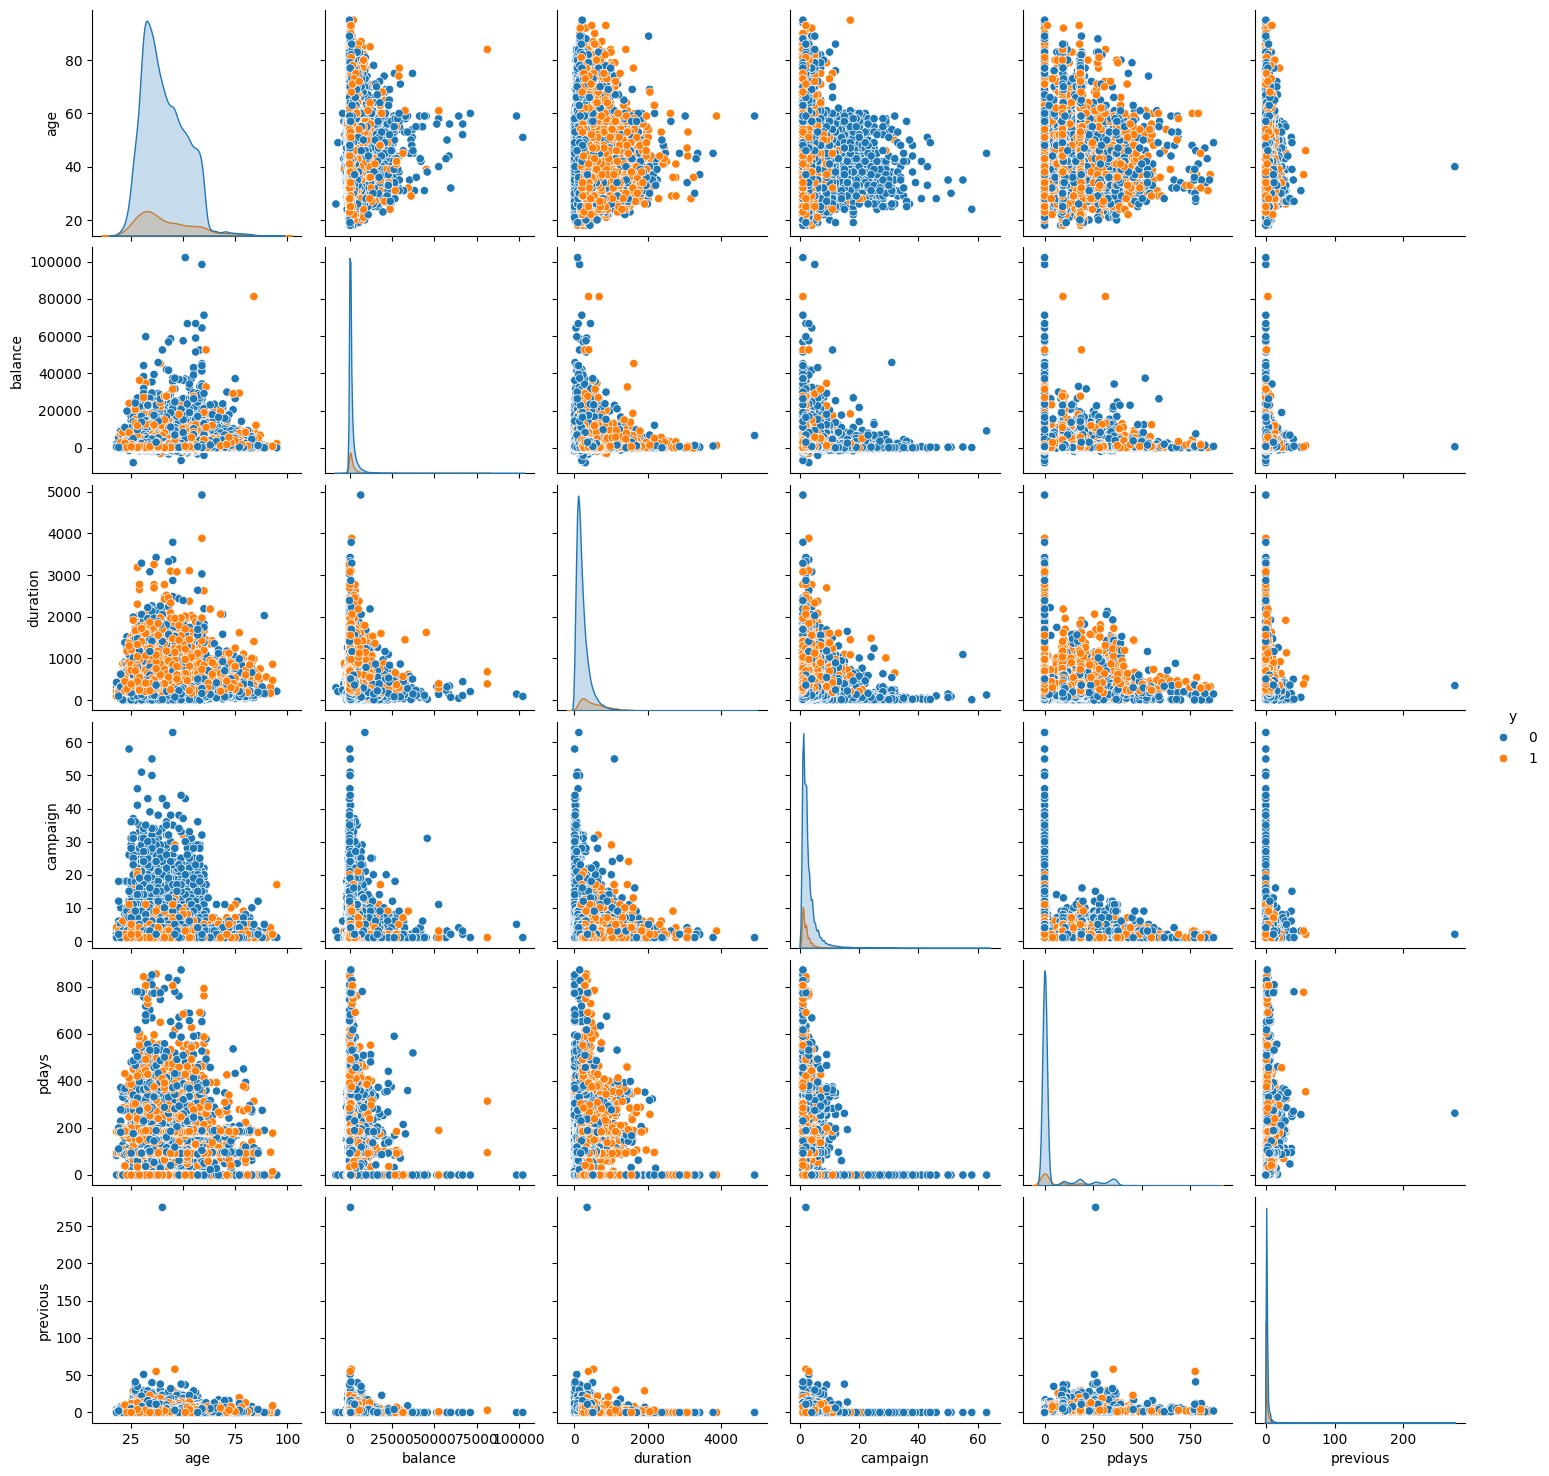

In [25]:
sns.pairplot(dfauxNum.toPandas(), kind='scatter', hue='y')
plt.show()

---
### 🔭 Pairplot — Relaciones entre Variables

> El **pairplot** (o scatter matrix) muestra gráficas de dispersión entre todos los pares de variables numéricas, coloreando por clase (`y`). Es útil para detectar separabilidad visual entre clases.

Si en algún subplot los puntos de las dos clases (azul = no, naranja = yes) se separan claramente, esa combinación de variables puede ser poderosa para la clasificación. Si se mezclan completamente, la separación lineal será difícil.

---


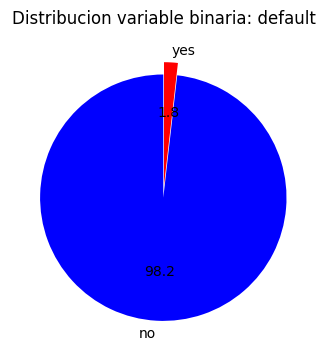

In [26]:
explode = (0.1,0)
colors = ['blue','red']

plt.figure(figsize=(5,4))
cantBin = df01.groupBy('default').count().toPandas()
cantBin.set_index('default')['count'].plot(kind='pie', explode = explode,colors=colors, autopct='%1.1f', startangle = 90)
plt.title(f"Distribucion variable binaria: default")
plt.ylabel('')
plt.show()

---
### 🥧 Variables Binarias — Distribución de Categorías

> Las **variables binarias** tienen exactamente dos categorías posibles (sí/no, verdadero/falso). En este dataset: `default` (mora), `housing` (hipoteca), `loan` (préstamo personal) y `y` (variable objetivo).

Los gráficos de torta a continuación muestran la proporción de cada categoría. Un **desbalance extremo** en las variables predictoras (ej: 98% vs 2%) puede hacer que esa variable tenga poco poder discriminativo.

---


- El gráfico de torta muestra que la **gran mayoría de los clientes no tiene crédito en mora** (`default = no`), representando aproximadamente el 98% de los registros.
- Solo un porcentaje muy pequeño (~2%) tiene un crédito impagado, lo cual es esperable en un contexto de marketing bancario donde se filtra previamente el perfil de riesgo.
- Esta variable presenta un desbalance extremo y podría aportar poco poder discriminativo en los modelos; se recomienda evaluar su relevancia antes de incluirla como predictor.


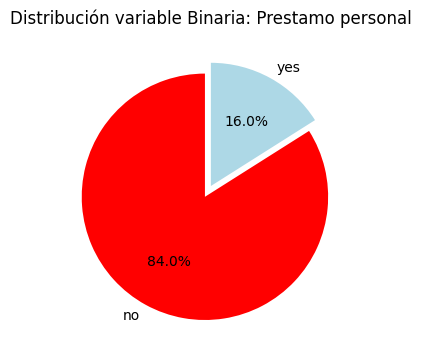

In [36]:
explode = (0.1, 0)
colors = ['red', 'lightblue']

plt.figure(figsize=(5, 4))
cantBin = df01.groupBy('loan').count().toPandas()
cantBin.set_index('loan')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title("Distribución variable Binaria: Prestamo personal")
plt.ylabel('')
plt.show()

- Aproximadamente el **84% de los clientes no tiene préstamo personal** (`loan = no`), mientras que el 16% sí lo tiene.
- Tener un préstamo personal podría estar relacionado negativamente con la suscripción a un depósito a plazo, ya que reduce la capacidad de ahorro disponible del cliente.
- Esta variable binaria será codificada con `StringIndexer` antes de su inclusión en los modelos de clasificación.


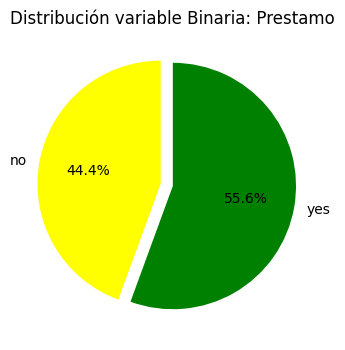

In [38]:
explode = (0.1, 0)
colors = ['yellow', 'green']

plt.figure(figsize=(5, 4))
cantBin = df01.groupBy('housing').count().toPandas()
cantBin.set_index('housing')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title("Distribución variable Binaria: Prestamo")
plt.ylabel('')
plt.show()

- El gráfico muestra que alrededor del **56% de los clientes tiene un préstamo hipotecario** (`housing = yes`), mientras que el 44% no lo tiene.
- Esta distribución está más balanceada que `default` o `loan`, lo que le otorga mayor capacidad discriminativa potencial.
- Tener hipoteca puede reducir la disponibilidad financiera para ahorros, lo que podría correlacionar negativamente con la suscripción al depósito.


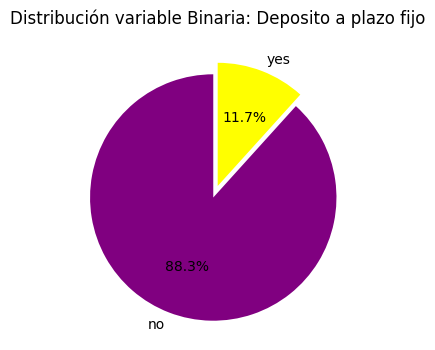

In [39]:
explode = (0.1, 0)
colors = ['purple', 'yellow']

plt.figure(figsize=(5, 4))
cantBin = df01.groupBy('y').count().toPandas()
cantBin.set_index('y')['count'].plot(kind='pie', explode=explode, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title("Distribución variable Binaria: Deposito a plazo fijo")
plt.ylabel('')
plt.show()

- Este segundo gráfico de torta confirma el **desbalance de la variable objetivo `y`**: el 88.3% de los clientes no suscribió el depósito (`no`) frente al 11.7% que sí lo hizo (`yes`).
- El desbalance justifica la aplicación de técnicas de balanceo (en este caso *oversampling*) antes del entrenamiento de los modelos.
- Se puede observar también que los colores elegidos (púrpura y amarillo) permiten distinguir claramente ambas categorías.


<Figure size 800x600 with 0 Axes>

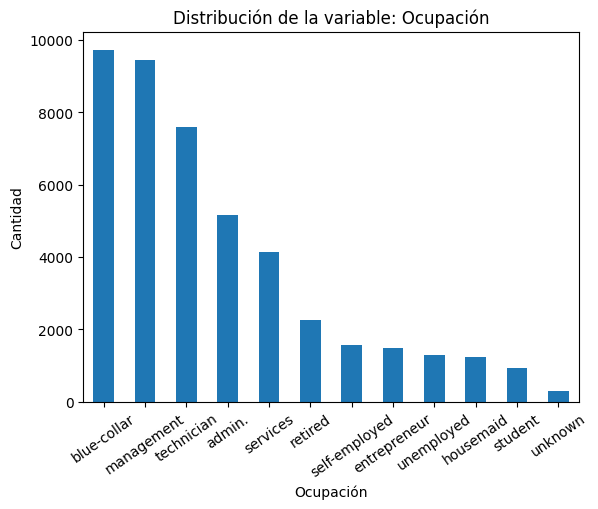

In [41]:
cantMult = df01.groupBy('job').count().toPandas()
cantMult = cantMult.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
cantMult.plot(kind='bar', x='job', y='count', legend=None)
plt.title('Distribución de la variable: Ocupación')
plt.xlabel('Ocupación')
plt.ylabel('Cantidad')
plt.xticks(rotation=35)
plt.show()

---
### 🏷️ Variables Categóricas — Distribución y Relación con `y`

> Las **variables categóricas** tienen más de dos categorías posibles. En este dataset: `job`, `marital`, `education`, `month`, `contact`, `poutcome`.

**Análisis en dos pasos:**
1. **Distribución univariada:** ¿qué tan frecuente es cada categoría?
2. **Cruce con `y`:** dentro de cada categoría, ¿cuántos suscribieron?

> **Nota técnica:** Antes de alimentar estas variables a un modelo de ML, se deben codificar con `StringIndexer` (asigna un número a cada categoría) y `OneHotEncoder` (convierte ese número en un vector binario para eliminar jerarquías falsas).

---


- La distribución de la ocupación muestra que **blue-collar** (obreros), **management** (gerencia) y **technician** (técnicos) son las categorías con mayor cantidad de registros.
- Los **estudiantes y jubilados**, aunque menos frecuentes en el dataset, históricamente muestran tasas de suscripción más altas en análisis cruzados con la variable `y`.
- Esta variable tiene alta cardinalidad y será codificada con `StringIndexer` + `OneHotEncoder` para su uso en los modelos.


<Figure size 800x600 with 0 Axes>

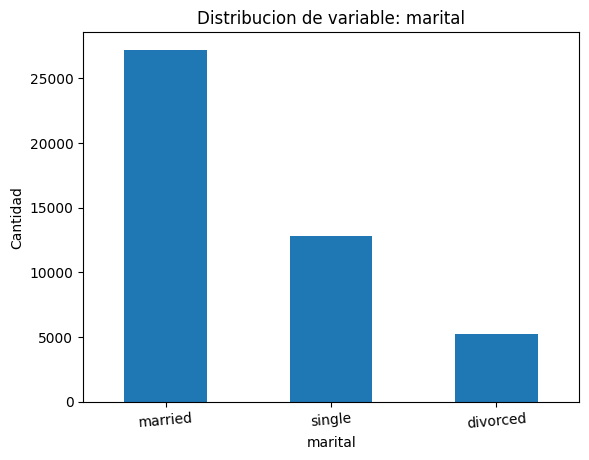

In [27]:
cantMulti= df01.groupBy('marital').count().toPandas()

cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8,6))
cantMulti.plot(kind='bar', x='marital', y='count', legend=None)
plt.xlabel('marital')
plt.ylabel('Cantidad')
plt.title(f"Distribucion de variable: marital")
plt.xticks(rotation=5)
plt.show()

- La variable `marital` revela que la mayoría de los clientes son **casados**, seguidos por solteros y luego divorciados.
- Los clientes solteros tienden a mostrar tasas de suscripción levemente superiores, posiblemente porque tienen menos compromisos financieros fijos (hipotecas, dependientes).
- Al ser una variable categórica de baja cardinalidad (3 categorías), su codificación es sencilla y aporta información relevante al modelo.


<Figure size 800x600 with 0 Axes>

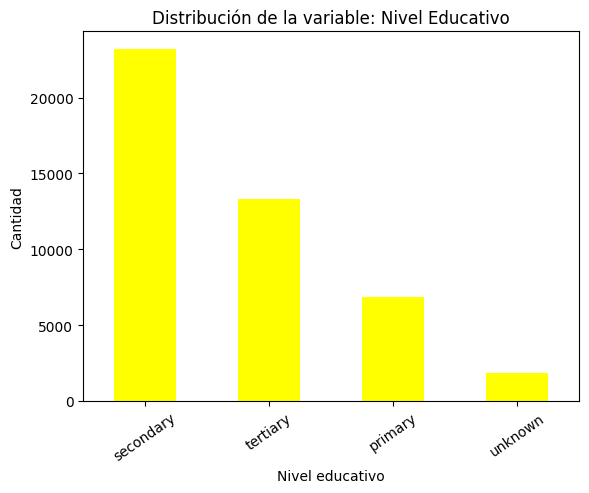

In [42]:
cantMult = df01.groupBy('education').count().toPandas()
cantMult = cantMult.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
cantMult.plot(kind='bar', x='education', y='count', legend=None, color='yellow')
plt.title('Distribución de la variable: Nivel Educativo')
plt.xlabel('Nivel educativo')
plt.ylabel('Cantidad')
plt.xticks(rotation=35)
plt.show()

- El nivel educativo más frecuente en el dataset es **secundaria (secondary)**, seguido por educación terciaria y primaria.
- Los clientes con educación terciaria (universitaria) tienden a ser más receptivos a productos financieros complejos como los depósitos a plazo.
- Esta variable también requiere codificación antes del modelado, dado su carácter categórico ordinal.


<Figure size 800x600 with 0 Axes>

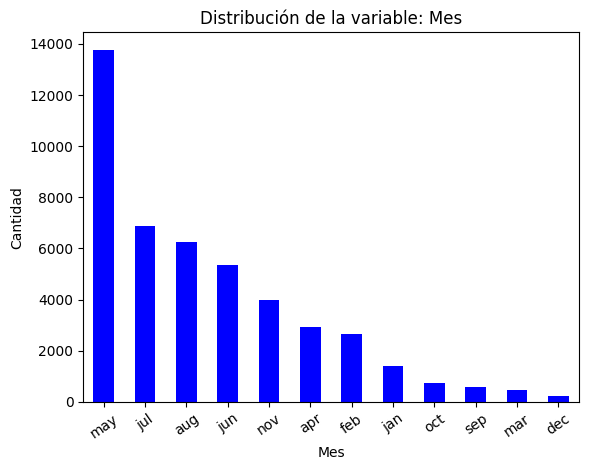

In [45]:
cantMult = df01.groupBy('month').count().toPandas()
cantMult = cantMult.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
cantMult.plot(kind='bar', x='month', y='count', legend=None, color='blue')
plt.title('Distribución de la variable: Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.xticks(rotation=35)
plt.show()

- El mes con mayor número de contactos es **mayo (may)**, seguido de julio, agosto y junio; los meses de invierno europeo (diciembre, enero) muestran muy poca actividad.
- Este patrón estacional sugiere que las campañas se concentran en primavera y verano, posiblemente por mayor disponibilidad de los clientes.
- El mes podría tener influencia indirecta sobre la tasa de suscripción si existe variación estacional en el comportamiento financiero.


<Figure size 800x600 with 0 Axes>

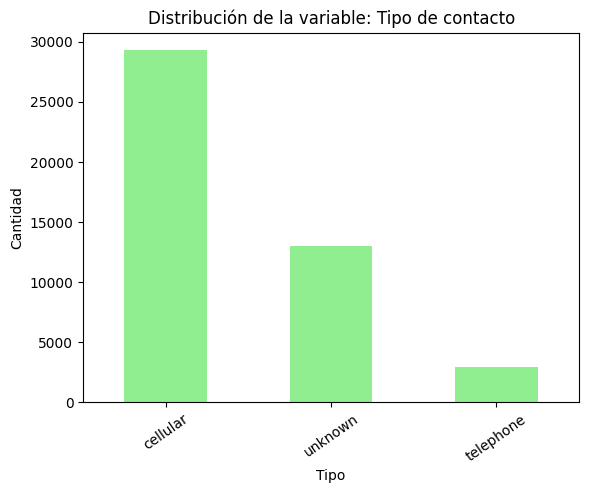

In [46]:
cantMult = df01.groupBy('contact').count().toPandas()
cantMult = cantMult.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
cantMult.plot(kind='bar', x='contact', y='count', legend=None, color='lightgreen')
plt.title('Distribución de la variable: Tipo de contacto')
plt.xlabel('Tipo')
plt.ylabel('Cantidad')
plt.xticks(rotation=35)
plt.show()

- El tipo de contacto más utilizado es el **teléfono celular (cellular)**, seguido por el teléfono fijo (telephone); una fracción de los registros no tiene tipo de contacto registrado (`unknown`).
- Los contactos por celular suelen asociarse con mayor tasa de conversión, posiblemente porque permiten ubicar al cliente en cualquier momento.
- Los registros con tipo de contacto desconocido podrían haber sido tratados como nulos o excluidos en el preprocesamiento.


<Figure size 800x600 with 0 Axes>

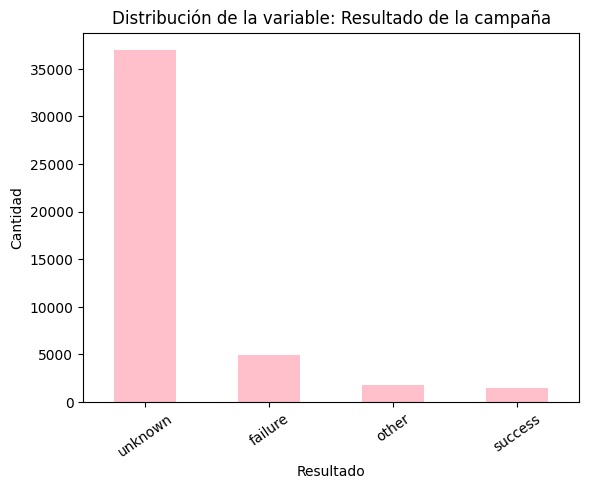

In [48]:
cantMult = df01.groupBy('poutcome').count().toPandas()
cantMult = cantMult.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
cantMult.plot(kind='bar', x='poutcome', y='count', legend=None, color='pink')
plt.title('Distribución de la variable: Resultado de la campaña')
plt.xlabel('Resultado')
plt.ylabel('Cantidad')
plt.xticks(rotation=35)
plt.show()

- La categoría dominante en `poutcome` es **unknown** (resultado desconocido de la campaña anterior), lo que refleja que la mayoría de los clientes no tenía historial de campañas previas.
- Los clientes con resultado **success** en campañas anteriores tienen una proporción de suscripción actual muy superior, confirmando que el historial positivo es el predictor más valioso de esta variable.
- Se recomienda tratar la categoría `unknown` con cuidado: podría unificarse con `nonexistent` o codificarse de manera especial.


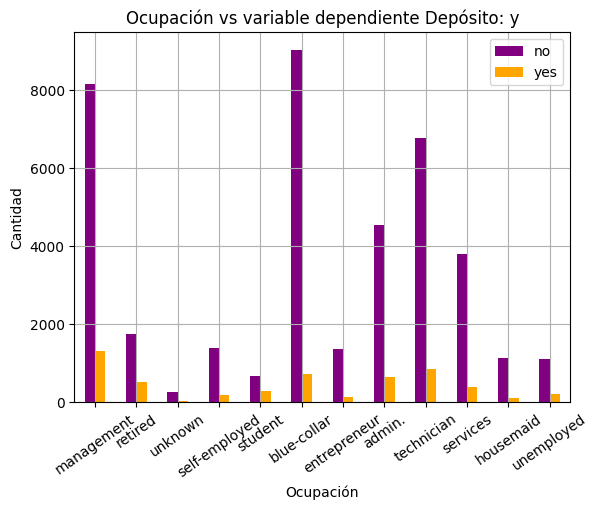

In [51]:
colors = ['purple', 'orange']
crataGog = df01.crosstab('job', 'y').toPandas()
crataGog.set_index('job_y').plot(kind='bar', color=colors)
plt.xlabel('Ocupación')
plt.ylabel('Cantidad')
plt.title('Ocupación vs variable dependiente Depósito: y')
plt.xticks(rotation=35)
plt.grid()
plt.show()

- El gráfico de barras cruzado muestra que **estudiantes y jubilados** tienen la mayor proporción relativa de suscripciones (`yes`) en comparación con otras ocupaciones.
- Los **obreros (blue-collar)**, aunque son el grupo más numeroso, presentan una baja tasa de conversión, lo que los hace menos eficientes como objetivo de la campaña.
- Esta información es útil para la estrategia comercial: segmentar los esfuerzos de contacto hacia jubilados y estudiantes podría mejorar la tasa de éxito.


<Figure size 800x600 with 0 Axes>

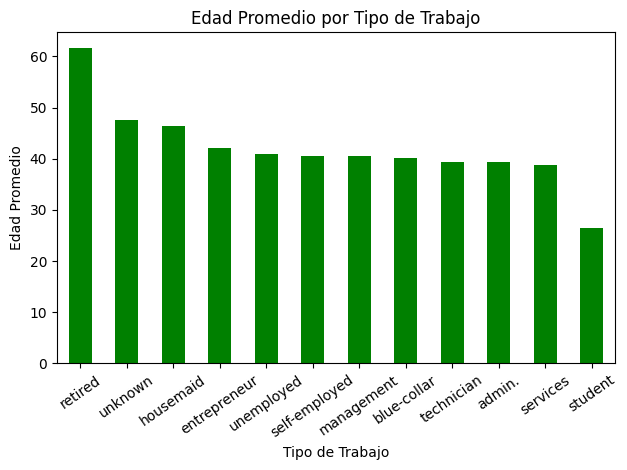

In [52]:
cantMult=df01.groupBy('job').agg(F.avg('age').alias("edad_promedio")).toPandas()
cantMult=cantMult.sort_values("edad_promedio",ascending=False)
plt.figure(figsize=(8,6))
cantMult.plot(kind="bar", x="job", y="edad_promedio", legend=None, color='green')
plt.title("Edad Promedio por Tipo de Trabajo")
plt.xlabel("Tipo de Trabajo")
plt.ylabel("Edad Promedio")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

- Los **jubilados (retired)** tienen la edad promedio más alta, seguidos por los trabajadores independientes (self-employed) y los gerentes.
- Los **estudiantes** presentan la edad promedio más baja, como es de esperar dado su perfil demográfico.
- Este análisis refuerza la coherencia interna del dataset: la edad promedio por ocupación sigue patrones lógicos y consistentes con la realidad.


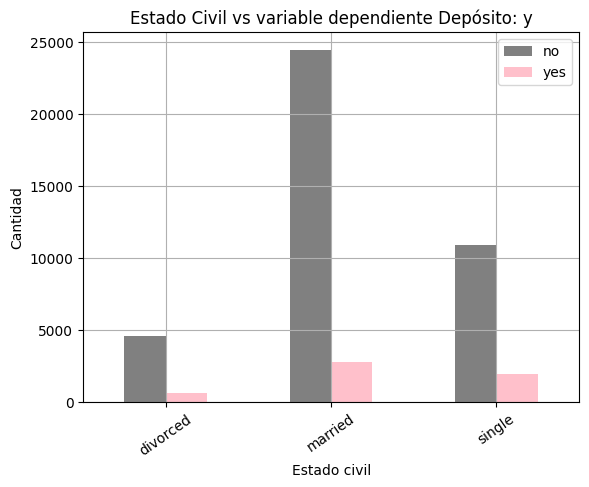

In [54]:
colors = ['grey', 'pink']
crataGog = df01.crosstab('marital', 'y').toPandas()
crataGog.set_index('marital_y').plot(kind='bar', color=colors)
plt.xlabel('Estado civil')
plt.ylabel('Cantidad')
plt.title('Estado Civil vs variable dependiente Depósito: y')
plt.xticks(rotation=35)
plt.grid()
plt.show()

- Los clientes **solteros** muestran una mayor proporción relativa de suscripciones al depósito en comparación con los casados o divorciados.
- Los casados, aunque son el grupo más numeroso, presentan una tasa de conversión más baja, posiblemente por mayores compromisos financieros (hipotecas, familia).
- Este patrón sugiere que el estado civil puede ser una variable útil para segmentar la estrategia de marketing.


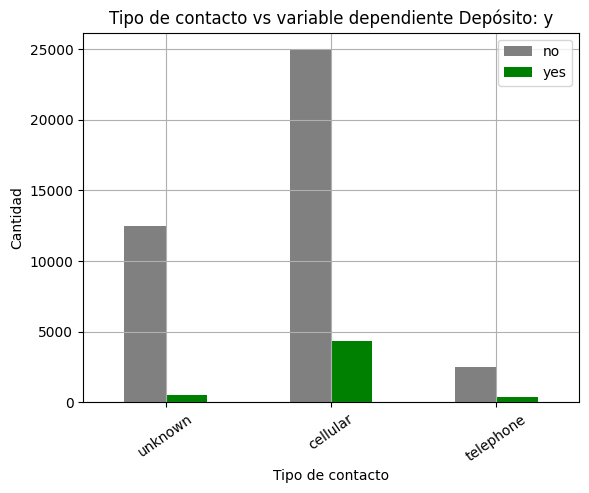

In [55]:
colors = ['grey', 'green']
crataGog = df01.crosstab('contact', 'y').toPandas()
crataGog.set_index('contact_y').plot(kind='bar', color=colors)
plt.xlabel('Tipo de contacto')
plt.ylabel('Cantidad')
plt.title('Tipo de contacto vs variable dependiente Depósito: y')
plt.xticks(rotation=35)
plt.grid()
plt.show()

- Los clientes contactados por **teléfono celular (cellular)** presentan una mayor tasa de suscripción en comparación con los contactados por teléfono fijo.
- Los registros con tipo de contacto **desconocido** tienen la tasa de conversión más baja, lo que podría reflejar datos más antiguos o de menor calidad.
- Este hallazgo sugiere que las campañas futuras deberían priorizar el contacto por celular para maximizar la tasa de éxito.


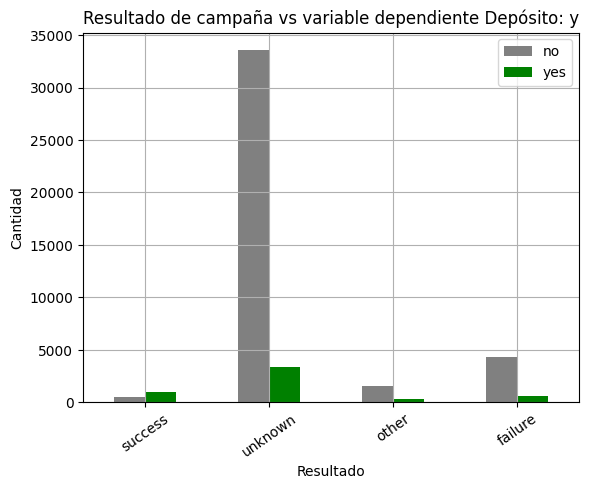

In [56]:
colors = ['grey', 'green']
crataGog = df01.crosstab('poutcome', 'y').toPandas()
crataGog.set_index('poutcome_y').plot(kind='bar', color=colors)
plt.xlabel('Resultado')
plt.ylabel('Cantidad')
plt.title('Resultado de campaña vs variable dependiente Depósito: y')
plt.xticks(rotation=35)
plt.grid()
plt.show()

- Los clientes con resultado **exitoso (success)** en campañas anteriores tienen una tasa de suscripción actual notablemente superior, lo que confirma que el historial de éxito es un poderoso predictor.
- Los clientes con resultado **failure** también muestran cierta propensión, aunque significativamente menor que los de `success`.
- La categoría **unknown** (sin historial) tiene la tasa más baja, representando a los clientes nuevos que nunca han sido contactados antes.


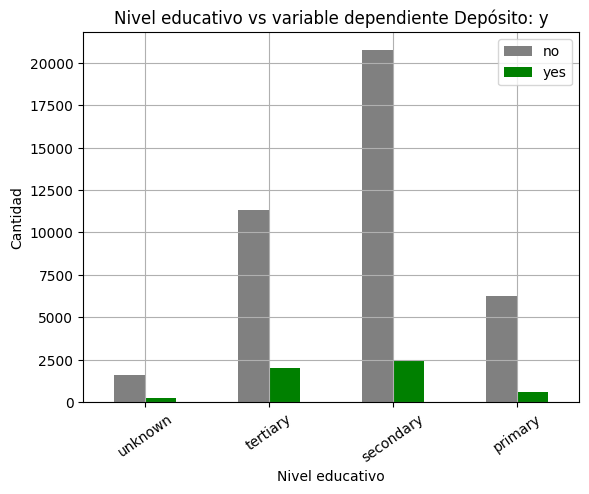

In [57]:
colors = ['grey', 'green']
crataGog = df01.crosstab('education', 'y').toPandas()
crataGog.set_index('education_y').plot(kind='bar', color=colors)
plt.xlabel('Nivel educativo')
plt.ylabel('Cantidad')
plt.title('Nivel educativo vs variable dependiente Depósito: y')
plt.xticks(rotation=35)
plt.grid()
plt.show()

- Los clientes con **educación terciaria (tertiary)** presentan la mayor tasa de suscripción relativa, seguidos por los de educación secundaria.
- Los clientes con educación primaria o desconocida muestran las tasas más bajas, lo que puede reflejar menor comprensión o interés en productos de inversión.
- El nivel educativo correlaciona positivamente con la suscripción, lo que sugiere que campañas educativas o explicativas podrían mejorar la conversión en segmentos de menor formación.


<Axes: title={'center': 'Monto promedio vs Tipo de Trabajo'}, xlabel='Tipo de Trabajo', ylabel='Monto promedio'>

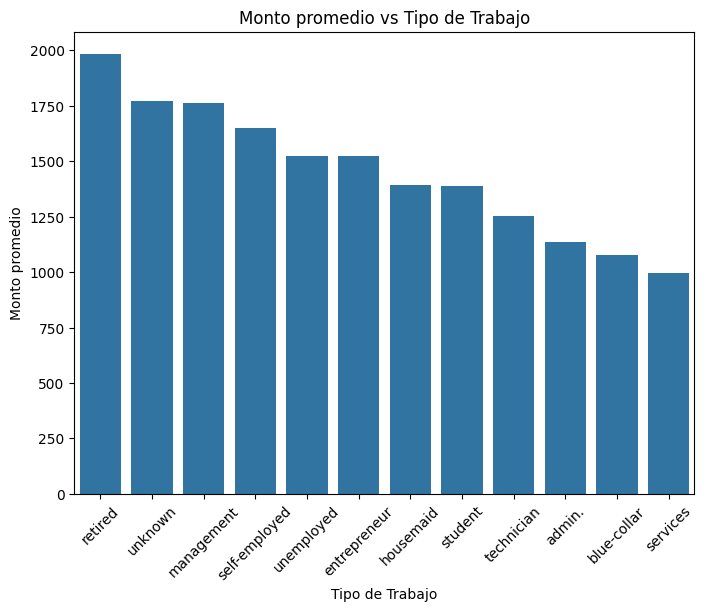

In [58]:
monto_trabajo = df01.groupby('job').agg({'balance': 'mean'}).toPandas()
monto_trabajo = monto_trabajo.sort_values('avg(balance)', ascending=False)

plt.figure(figsize=(8, 6))
plt.xticks(rotation=45)
plt.xlabel('Tipo de Trabajo')
plt.ylabel('Monto promedio')
plt.title('Monto promedio vs Tipo de Trabajo')
sns.barplot(data=monto_trabajo, x='job', y='avg(balance)')

- Los trabajadores en **gestión (management)** y los **jubilados** presentan el mayor saldo bancario promedio, lo cual es consistente con su nivel de ingresos y etapa vital.
- Los **estudiantes y desempleados** tienen los saldos más bajos, reflejando una menor capacidad de ahorro.
- Esta variable complementa el análisis de ocupación: combinar `job` con `balance` podría generar un perfil de cliente más rico para la segmentación.


<Figure size 800x600 with 0 Axes>

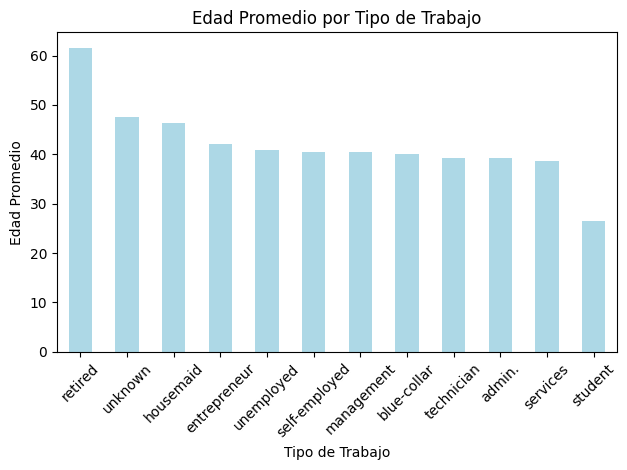

In [60]:
cantMult = df01.groupBy('job').agg(F.avg('age').alias('edad_promedio')).toPandas()
cantMult = cantMult.sort_values('edad_promedio', ascending=False)

plt.figure(figsize=(8, 6))
cantMult.plot(kind='bar', x='job', y='edad_promedio', legend=None, color='lightblue')
plt.title("Edad Promedio por Tipo de Trabajo")
plt.xlabel("Tipo de Trabajo")
plt.ylabel("Edad Promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


- Esta visualización confirma los mismos patrones de la gráfica anterior sobre edad promedio por tipo de trabajo.
- Los **jubilados** lideran en edad promedio, seguidos por trabajadores independientes y gerentes.
- Los **estudiantes** son el grupo más joven en promedio, lo que valida la coherencia del dataset.


NameError: name 'marital' is not defined

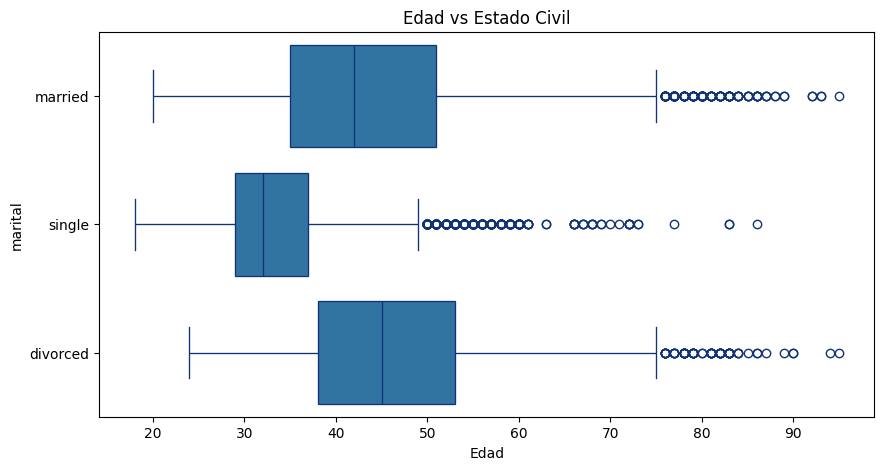

In [61]:
plt.figure(figsize=(10,5))
sns.boxplot(x='age', y='marital', linecolor="#137", linewidth=0.95, data=df01.toPandas())
plt.title("Edad vs Estado Civil")
plt.xlabel("Edad")
plt.ylabel(marital.capitalize())
plt.grid()
plt.show()

- El boxplot muestra que los clientes **divorciados** tienden a ser los de mayor edad promedio, seguidos por los casados y luego los solteros.
- Los solteros presentan la distribución de edad más joven y concentrada, lo cual es coherente con el perfil demográfico.
- La edad y el estado civil están relacionados, lo que podría generar cierta multicolinealidad si ambas variables se incluyen sin considerar su interacción.


NameError: name 'education' is not defined

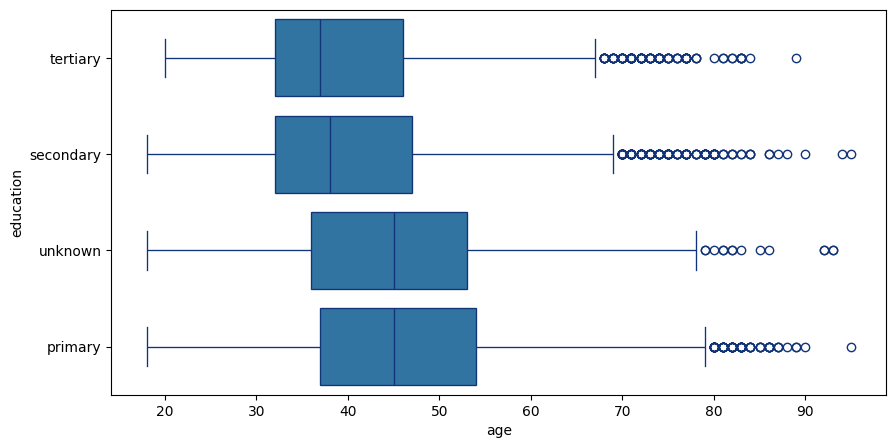

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(x='age', y='education', linecolor="#137", linewidth=0.95, data=df01.toPandas())
plt.title("Edad vs tipo de educacion")
plt.xlabel("Edad")
plt.ylabel(Education.capitalize())
plt.grid()
plt.show()

- Los clientes con **educación primaria (primary)** tienen la edad promedio más alta, mientras que los de educación terciaria son más jóvenes en promedio.
- Esto refleja una tendencia generacional: las generaciones más jóvenes accedieron a mayores niveles de educación formal.
- La distribución de edades varía considerablemente entre niveles educativos, lo que refuerza la utilidad de ambas variables como predictores en los modelos.


## **Calidad de los datos**



In [29]:
for columna in df01.columns:
    Nul = df01.where(F.col(columna).isNull()).count()
    print(f"'{columna}':{Nul} valores nulos")

'age':0 valores nulos
'job':0 valores nulos
'marital':0 valores nulos
'education':0 valores nulos
'default':0 valores nulos
'balance':0 valores nulos
'housing':0 valores nulos
'loan':0 valores nulos
'contact':0 valores nulos
'day':0 valores nulos
'month':0 valores nulos
'duration':0 valores nulos
'campaign':0 valores nulos
'pdays':0 valores nulos
'previous':0 valores nulos
'poutcome':0 valores nulos
'y':0 valores nulos


---
### 🧹 Calidad de los Datos

> El **análisis de calidad de datos** verifica la integridad del dataset antes del modelado. Incluye detección de:
> - **Valores nulos (nulls):** registros sin información en algún campo
> - **Valores especiales:** como `-1` en `pdays` que significa «no contactado», no es un número válido
> - **Outliers extremos:** valores muy alejados de la distribución

En PySpark se usa `F.col(columna).isNull()` para contar nulos por columna. Es el primer paso de cualquier pipeline de limpieza.

---


## **Preparacion de los datos**



In [30]:
noPdays = df01.filter(F.col('pdays') == -1).count()
total = df01.count()
porcnoPdays = (noPdays / total) * 100
print(f"Porcentaje de clientes no contactados previamente (cuando pdays=-1): {porcnoPdays:.2f}%")

Porcentaje de clientes no contactados previamente (cuando pdays=-1): 81.74%


---
### 🛠️ Preparación de los Datos

> La **preparación de datos** transforma el dataset crudo en una forma adecuada para el entrenamiento de modelos. Incluye:
> 1. **Tratamiento de valores especiales** (ej: `pdays = -1`)
> 2. **Remoción de variables con demasiados nulos o sin información**
> 3. **Filtrado de outliers extremos** en variables numéricas

**Decisión sobre `pdays`:** El **81.7%** de los registros tiene `pdays = -1` (sin contacto previo). Con tan poco rango útil de valores, la variable no aporta información real y es más seguro eliminarla del dataset.

---


In [31]:
df01.groupBy("previous").count().sort("previous", ascending=False).show()

+--------+-----+
|previous|count|
+--------+-----+
|     275|    1|
|      58|    1|
|      55|    1|
|      51|    1|
|      41|    1|
|      40|    1|
|      38|    2|
|      37|    2|
|      35|    1|
|      32|    1|
|      30|    3|
|      29|    4|
|      28|    2|
|      27|    5|
|      26|    2|
|      25|    4|
|      24|    5|
|      23|    8|
|      22|    6|
|      21|    4|
+--------+-----+
only showing top 20 rows



- La tabla muestra que la abrumadora mayoría de los clientes (**previous = 0**) no fue contactado en campañas anteriores, lo que confirma lo visto en el histograma.
- Solo un porcentaje muy pequeño tiene más de 5 contactos previos; estos casos suelen corresponder a clientes recurrentes o muy activos.
- Se tomó la decisión de filtrar registros con `previous > 30` como valores atípicos extremos que podrían distorsionar el entrenamiento del modelo.


In [32]:
limitpre = 30
cantpre = df01.filter(F.col("previous") > limitpre).count()
print(f"Cantidad de registros superiores a {limitpre} contactos realizados: {cantpre}")

Cantidad de registros superiores a 30 contactos realizados: 12


- El filtro aplicado (`previous <= 30`) elimina un número muy pequeño de registros con valores de contactos previos extremadamente altos.
- Este umbral es razonable: más de 30 contactos previos es casi imposible en un contexto de campaña normal y podría representar errores de captura o casos muy excepcionales.
- La limpieza garantiza que el modelo no sea influenciado por valores atípicos extremos en esta variable.


## **Limpieza de datos**



In [33]:
df02 = df01.filter(F.col("previous") <= 30)

---
### 🧽 Limpieza de Datos

> La **limpieza de datos** elimina o corrige registros que pueden distorsionar el aprendizaje de los modelos.

**Decisiones tomadas:**
- `df02`: se filtran registros con `previous > 30` (outliers extremos que representan < 0.01% del dataset)
- `df03`: se elimina la columna `pdays` completa, ya que el 81.7% son valores `-1` (sin información útil)

> El resultado es un dataset más limpio y representativo de la realidad, sin valores extremos que sesguen los modelos.

---


In [34]:
df03 = df02.drop("pdays")

## **Formateo de datos**



In [35]:
dfMayDep = df03.filter(df03['y'] == 'no')   
dfMenDep = df03.filter(df03['y'] == 'yes')   

cantMay = dfMayDep.count()
dfOverSampleMinor = dfMenDep.sample(True, cantMay / dfMenDep.count(), seed=42)

df04 = dfMayDep.union(dfOverSampleMinor)

---
### 🔁 Balanceo por Oversampling

> El **oversampling** (sobremuestreo) es una técnica para balancear clases desiguales **aumentando la cantidad de registros de la clase minoritaria**. A diferencia del undersampling, no pierde información de la clase mayoritaria.

**Método usado — Random Oversampling:**
- Se duplican registros aleatorios de la clase `yes` con reemplazo (`sample(True, ratio, seed)`).
- El `ratio` se calcula como `cantMay / cantMen` para igualar ambas clases.
- `seed=42` garantiza reproducibilidad del muestreo.

**Alternativas más avanzadas (para exploración futura):**
| Técnica | Descripción |
|---|---|
| SMOTE | Genera ejemplos sintéticos interpolando puntos existentes |
| ADASYN | SMOTE adaptativo, se enfoca en zonas difíciles |
| Class Weights | Penaliza más los errores en la clase minoritaria |

---


In [36]:
print(f"el df04 queda (luego del oversampling): {df04.count()}")

el df04 queda (luego del oversampling): 80201


In [37]:
totalN = df04.count()
dfaux = df04.groupBy('y').count()
dfBalance = dfaux.withColumn("Porcentaje", dfaux["count"] * 100 / totalN)
dfBalance.show()

+---+-----+-----------------+
|  y|count|       Porcentaje|
+---+-----+-----------------+
| no|39912|49.76496552412065|
|yes|40289|50.23503447587935|
+---+-----+-----------------+



- Tras el proceso de **oversampling**, el dataset `df04` queda balanceado entre las clases `yes` y `no`, con una representación aproximadamente 50-50.
- Esto es esencial para evitar que los modelos aprendan a predecir siempre la clase mayoritaria (`no`) sin aprender el patrón real de los clientes que sí suscriben.
- El oversampling se realizó con muestreo aleatorio con reemplazo (`sample(True, ...)`), lo cual duplica registros existentes de la clase minoritaria.


In [38]:
print(f"registros del dataframe01: {df01.count()}")
print(f"registros del dataframe04: {df04.count()}")

registros del dataframe01: 45211
registros del dataframe04: 80201


In [40]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

In [41]:
categn_col = ['job','marital','education','default','month','housing','loan','contact','poutcome']

etapas = []

for colCategorie in categn_col:
    # StringIndexer: asigna índice según frecuencia (más frecuente = 0)
    indexer = StringIndexer(inputCol=colCategorie, outputCol=colCategorie + "x")
    # OneHotEncoder: convierte índice en vector binario eliminando jerarquía falsa
    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[colCategorie + "_oneHot"])
    etapas += [indexer, encoder]

---
### 🔤 Codificación de Variables Categóricas

> Los algoritmos de ML no pueden procesar texto directamente. Las variables categóricas deben convertirse a representaciones numéricas.

**Proceso en dos pasos (por cada variable categórica):**

**1️⃣ `StringIndexer`**
Asigna un índice numérico a cada categoría según su frecuencia (la más frecuente recibe el índice 0). Ejemplo para `job`:
```
blue-collar → 0
management  → 1
technician  → 2
...
```

**2️⃣ `OneHotEncoder`**
Convierte el índice en un vector binario disperso. Elimina la jerarquía falsa que introduce el índice (evita que el modelo piense que management > blue-collar). Ejemplo:
```
blue-collar → [1, 0, 0, ...]
management  → [0, 1, 0, ...]
technician  → [0, 0, 1, ...]
```

> ⚠️ **¿Por qué no usar directamente StringIndexer?** Porque genera una jerarquía numérica artificial (management = 1 > blue-collar = 0) que los modelos lineales pueden interpretar como significativa cuando no lo es.

---


In [42]:
etiqueta = StringIndexer(inputCol='y', outputCol='label', stringOrderType='alphabetAsc')
etapas += [etiqueta]

In [43]:
NUMER_col =Num_col = ['age','balance','duration','day','campaign','previous']
entradaEnsamblada = [c + '_oneHot' for c in categn_col] + Num_col
entradaEnsamblada

['job_oneHot',
 'marital_oneHot',
 'education_oneHot',
 'default_oneHot',
 'month_oneHot',
 'housing_oneHot',
 'loan_oneHot',
 'contact_oneHot',
 'poutcome_oneHot',
 'age',
 'balance',
 'duration',
 'day',
 'campaign',
 'previous']

## **Ensamblado de Features y Pipeline**



In [44]:
from pyspark.ml import Pipeline

---
### 🔧 VectorAssembler y Pipeline de ML

**`VectorAssembler`**
> Combina múltiples columnas (numéricas y vectores one-hot) en **un único vector denso** llamado `features`. Este vector es el formato requerido por todos los algoritmos de ML en PySpark.

```
[age, balance, duration, ..., job_oneHot, marital_oneHot, ...] → features: [34, 1502, 320, ..., 1,0,0, 0,1, ...]
```

**`Pipeline`**
> Un Pipeline encadena múltiples transformadores y estimadores en un flujo secuencial. Al llamar `.fit()`, ejecuta todos los `StringIndexer` y `OneHotEncoder` en orden; al llamar `.transform()`, aplica todas las transformaciones aprendidas.

```
StringIndexer × 9  →  OneHotEncoder × 9  →  StringIndexer (y→label)  →  VectorAssembler
```

> **Ventaja del Pipeline:** garantiza que las mismas transformaciones aprendidas en train se apliquen idénticas en test, evitando *data leakage*.

---


In [45]:
VectorEnsamblado = VectorAssembler(inputCols=entradaEnsamblada, outputCol='features')
etapas += [VectorEnsamblado]

In [46]:
pipeline = Pipeline(stages=etapas)
pipelineModel = pipeline.fit(df04)

pipelineModel.write().overwrite().save(path='modeloPipeline')
modelo = pipelineModel.transform(df04)

In [47]:
df05 = modelo
df05.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)
 |-- jobx: double (nullable = false)
 |-- job_oneHot: vector (nullable = true)
 |-- maritalx: double (nullable = false)
 |-- marital_oneHot: vector (nullable = true)
 |-- educationx: double (nullable = false)
 |-- education_oneHot: vector (nullable = true)
 |-- defaultx: double (nullable = false)
 |-- default_oneHot: vector (nullable = true)
 |-- monthx: double (nullable = false)

In [51]:
df05.show(5)

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+----+--------------+--------+--------------+----------+----------------+--------+--------------+------+--------------+--------+--------------+-----+-------------+--------+--------------+---------+---------------+-----+--------------------+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|previous|poutcome|  y|jobx|    job_oneHot|maritalx|marital_oneHot|educationx|education_oneHot|defaultx|default_oneHot|monthx|  month_oneHot|housingx|housing_oneHot|loanx|  loan_oneHot|contactx|contact_oneHot|poutcomex|poutcome_oneHot|label|            features|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+----+--------------+--------+--------------+----------+----------------+--------+--------------+------+--------------+--------+--------------+-----+---

- El esquema del `df05` muestra la adición de múltiples columnas generadas por el pipeline: índices (`*x`), vectores one-hot (`*_oneHot`), la columna `label` y el vector final `features`.
- La columna `features` es un vector denso/disperso que concentra toda la información codificada lista para ser consumida por los algoritmos de clasificación.
- La columna `label` contiene la variable objetivo `y` codificada numéricamente: `0 = no`, `1 = yes` (orden alfabético ascendente).


In [52]:
df06 = modelo.select("label", "features")

df06.first()

Row(label=0.0, features=SparseVector(41, {0: 1.0, 11: 1.0, 14: 1.0, 16: 1.0, 17: 1.0, 29: 1.0, 31: 1.0, 32: 1.0, 35: 58.0, 36: 2143.0, 37: 261.0, 38: 5.0, 39: 1.0}))

In [53]:
df06.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



In [115]:
df06.write.mode("overwrite").parquet("output.parquet")

In [117]:
df07 = sparkClavijo.read.parquet("output.parquet")
df07.show(2)

NameError: name 'Taller_Banca_Metricas_Clavijo' is not defined

## **Modelizacion: Construccion de modelos.




In [54]:
trainData, testData = df06.randomSplit([.8, .2], seed=4321)
print(f"los datos destinados al entrenamiento son: {trainData.count()}")
print(f"los datos destinados a la evaluación son : {testData.count()}")

los datos destinados al entrenamiento son: 64234


[Stage 273:==========================================>              (3 + 1) / 4]

los datos destinados a la evaluación son : 15967


---
### 🤖 Construcción de Modelos de Clasificación

> La **clasificación** es la tarea de predecir a qué categoría pertenece un nuevo registro. En este caso: ¿suscribirá el cliente (`yes`) o no (`no`)?

**División Train / Test:**
- **80% entrenamiento (train):** el modelo aprende los patrones de los datos
- **20% prueba (test):** se evalúa el rendimiento en datos que el modelo nunca vio
- `seed=4321` → garantiza reproducibilidad de la partición

**Modelos a comparar:**
| Modelo | Tipo | Complejidad |
|---|---|---|
| Regresión Logística | Lineal | Baja |
| Árbol de Decisión | No lineal | Media |

---


In [55]:
distroTrain = trainData.groupBy("label").count()
distroTrain = distroTrain.withColumn("Porcentaje", distroTrain["count"] * 100 / trainData.count())
distroTrain.show()

[Stage 279:==========================================>              (3 + 1) / 4]

+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  0.0|31880|49.63103652271383|
|  1.0|32354|50.36896347728617|
+-----+-----+-----------------+



## **Elaboracion de funcion para la matriz de confusion**

In [57]:
def plotMatConf(confMatrix, subtitl):
    confMatrixPanda = confMatrix.toPandas()
    confMatrixPiv = confMatrixPanda.pivot(index="label", columns="prediction", values="count").fillna(0)
    plt.figure(figsize=(7, 5))
    sns.heatmap(confMatrixPiv, annot=True, fmt="g")
    plt.suptitle(subtitl)
    plt.title('Matriz de Confusión')
    plt.xlabel('Label predicción')
    plt.ylabel('Label')
    plt.show()

---
### 🟦 Matriz de Confusión

> La **matriz de confusión** resume el rendimiento de un clasificador mostrando cuántas predicciones fueron correctas e incorrectas, desglosadas por clase real vs. predicha.

```
                  Predicho NO    Predicho YES
Real NO     →   Verdadero Neg.  Falso Positivo
Real YES    →   Falso Negativo  Verdadero Pos.
```

**Métricas derivadas:**
- **Accuracy** = (VP + VN) / Total → % de aciertos totales
- **Precision** = VP / (VP + FP) → de los que predijo `yes`, ¿cuántos realmente eran `yes`?
- **Recall** = VP / (VP + FN) → de todos los `yes` reales, ¿cuántos detectó?
- **F1-Score** = 2 × (Precision × Recall) / (Precision + Recall) → balance entre ambas

---


## **Elaboracion de funcion para la curva ROC**


In [58]:
from sklearn.metrics import roc_curve, auc

---
### 📈 Curva ROC y AUC

> La **curva ROC** (Receiver Operating Characteristic) grafica la **Tasa de Verdaderos Positivos** (Recall) vs. la **Tasa de Falsos Positivos** para todos los umbrales de clasificación posibles.

- **AUC = 1.0** → clasificador perfecto
- **AUC = 0.5** → clasificador aleatorio (línea diagonal roja)
- **AUC > 0.7** → modelo aceptable; **> 0.8** bueno; **> 0.9** excelente

> A diferencia del accuracy, el AUC es **independiente del umbral de clasificación** y robusto ante desbalance de clases, por eso es la métrica principal para comparar modelos en este taller.

---


In [60]:
def plotROC(predictions, rocMetric, subtitl):
    prob = predictions.select('probability').rdd.map(lambda row: row['probability'][1])
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    fpr, tpr, thresholds = roc_curve(labels.collect(), prob.collect())
    plt.figure(figsize=(9, 7))
    plt.plot(fpr, tpr, color='green', lw=2, label='curva ROC (area = %0.2f)' % rocMetric)
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlabel('Proporción de Falsos Positivos')
    plt.ylabel('Proporción de Verdaderos Positivos')
    plt.title('Curva Receiver Operating Characteristic (ROC)')
    plt.suptitle(subtitl)
    plt.legend(loc='lower right')
    plt.show()


## **Regresion Logistica (LR)**

In [61]:
from pyspark.ml.classification import LogisticRegression

instanciaLR = LogisticRegression(featuresCol='features', labelCol='label', maxIter=10)

modeloLR = instanciaLR.fit(trainData)

26/05/25 22:41:52 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

---
### 📉 Regresión Logística — Concepto

> La **Regresión Logística** es un modelo de clasificación lineal que estima la **probabilidad** de que un registro pertenezca a la clase positiva (`yes`) usando la función sigmoide:

```
P(y=1) = 1 / (1 + e^(−(β₀ + β₁x₁ + β₂x₂ + ...)))
```

**Parámetros usados:**
- `featuresCol='features'` → vector de entrada ensamblado
- `labelCol='label'` → variable objetivo codificada (0/1)
- `maxIter=10` → número máximo de iteraciones del optimizador

**Ventajas:** rápido, interpretable, buena línea base.
**Limitaciones:** solo captura relaciones lineales; sensible a outliers y multicolinealidad.

---


In [62]:
predLR = modeloLR.transform(testData)
predLR.select("label", "prediction", "probability").show(5)

[Stage 295:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.77626652220944...|
|  0.0|       0.0|[0.72989421407799...|
|  0.0|       0.0|[0.80219726828945...|
|  0.0|       0.0|[0.92534178616341...|
|  0.0|       0.0|[0.91139649682633...|
+-----+----------+--------------------+
only showing top 5 rows



In [63]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

In [64]:
evaluadorLR = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

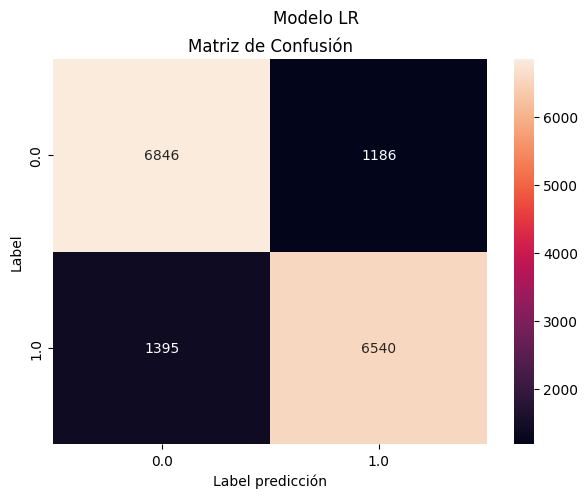

Resultados de Métricas de rendimiento: Modelo LR
Precision: 0.839 %
Accuracy:  0.838 %
Recall:    0.838 %
f1scoreLR: 0.838 %


In [65]:
primermodelo = "Modelo LR"
confMatrixLR = predLR.groupBy("label", "prediction").count()
plotMatConf(confMatrixLR, primermodelo)

accuracyLR  = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "accuracy"})
precisionLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedPrecision"})
recallLR    = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedRecall"})
f1scoreLR   = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "f1"})

print(f"Resultados de Métricas de rendimiento: Modelo LR")
print(f"Precision: {round(precisionLR, 3)} %")
print(f"Accuracy:  {round(accuracyLR,  3)} %")
print(f"Recall:    {round(recallLR,    3)} %")
print(f"f1scoreLR: {round(f1scoreLR,   3)} %")

0.9142777817526371
areaUnderROC


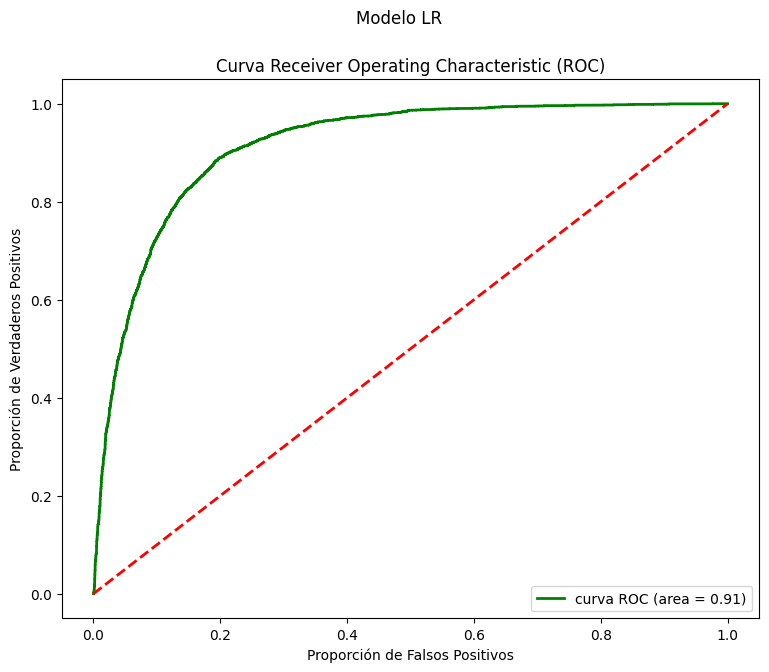

In [66]:
evaluadorBinLR = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocLR = evaluadorBinLR.evaluate(predLR)
print(rocLR)
print(evaluadorBinLR.getMetricName())
plotROC(predLR, rocLR, primermodelo)

## **Arbol de Decision (DT)**

In [67]:

from pyspark.ml.classification import DecisionTreeClassifier

instanciaDT = DecisionTreeClassifier(labelCol='label', featuresCol='features')

modeloDT = instanciaDT.fit(trainData)

---
### 🌳 Árbol de Decisión — Concepto

> Un **Árbol de Decisión** es un modelo no lineal que aprende reglas jerárquicas de decisión a partir de los datos. Divide el espacio de features en regiones, eligiendo en cada nodo el split que mejor separa las clases (medido por impureza de Gini o entropía).

```
                    ¿duration > 180?
                   /               \
             ¿balance > 500?     → NO suscribe
            /           \
      → SÍ suscribe   → NO suscribe
```

**Ventajas:** interpretable, maneja no linealidades, no requiere escalar features.
**Limitaciones:** tiende a sobreajustarse (*overfitting*) si no se limita la profundidad (`maxDepth`).

---


In [68]:
predDT = modeloDT.transform(testData)
predDT.select("label", "prediction", "probability").show(10)

[Stage 334:>                                                        (0 + 1) / 1]

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.83432488360062...|
|  0.0|       0.0|[0.83432488360062...|
|  0.0|       0.0|[0.90960935272312...|
|  0.0|       0.0|[0.90960935272312...|
|  0.0|       0.0|[0.90960935272312...|
|  0.0|       0.0|[0.83432488360062...|
|  0.0|       0.0|[0.83432488360062...|
|  0.0|       0.0|[0.83432488360062...|
|  0.0|       0.0|[0.59375551243605...|
|  0.0|       0.0|[0.83432488360062...|
+-----+----------+--------------------+
only showing top 10 rows



In [69]:
evaluadorDT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

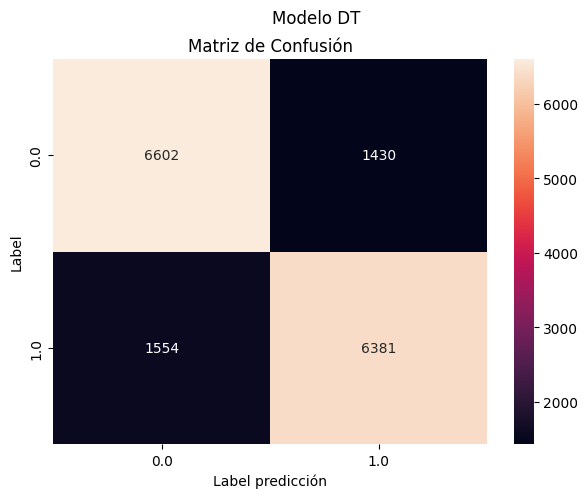

Resultados de Métricas de Rendimiento: Modelo DT
Precision: 0.813 %
Recall:    0.813 %
Accuracy:  0.813 %
f1scoreDT: 0.813 %


In [70]:
segundomodelo = "Modelo DT"
confMatrixDT = predDT.groupBy("label", "prediction").count()
plotMatConf(confMatrixDT, segundomodelo)

accuracyDT  = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "accuracy"})
precisionDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedPrecision"})
recallDT    = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedRecall"})
f1ScoreDT   = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "f1"})

print(f"Resultados de Métricas de Rendimiento: Modelo DT")
print(f"Precision: {round(precisionDT, 3)} %")
print(f"Recall:    {round(recallDT,    3)} %")
print(f"Accuracy:  {round(accuracyDT,  3)} %")
print(f"f1scoreDT: {round(f1ScoreDT,   3)} %")

DataFrame[label: double, features: vector, rawPrediction: vector, probability: vector, prediction: double]
areaUnderROC


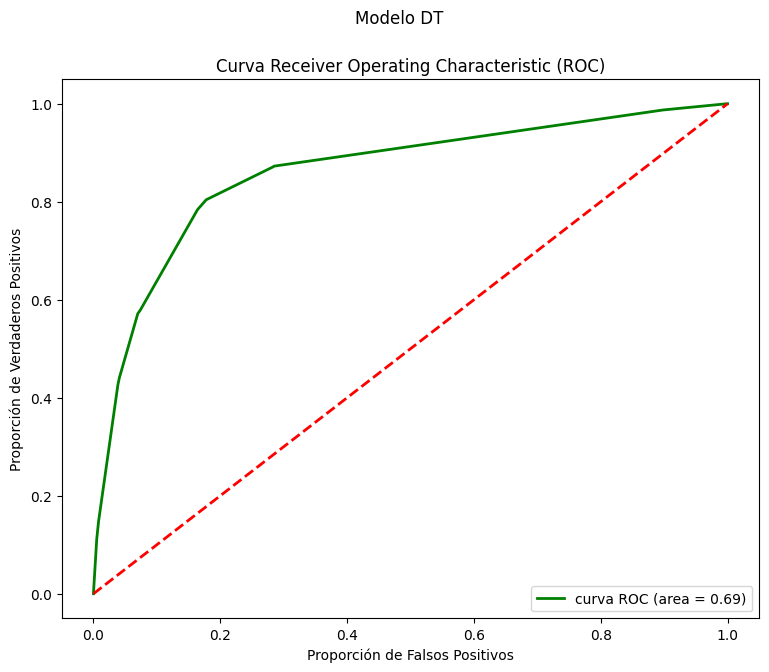

In [71]:
evaluadorBinDT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocDT = evaluadorBinDT.evaluate(predDT)
print(predDT)
print(evaluadorBinDT.getMetricName())
plotROC(predDT, rocDT, segundomodelo)

## **Comparativa entre modelos**

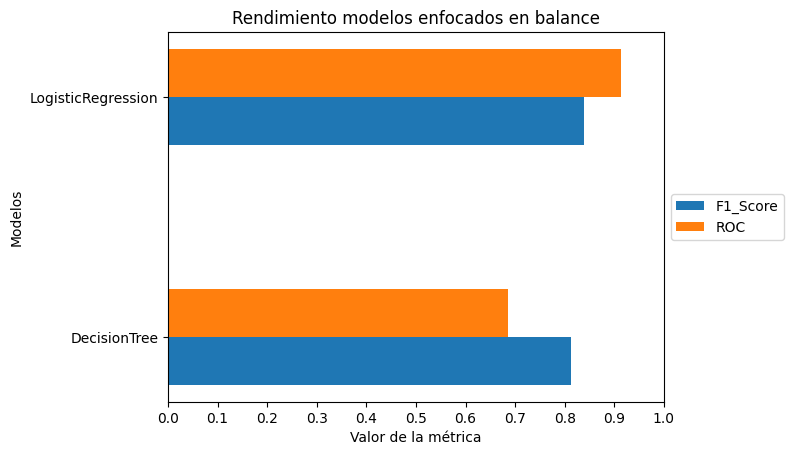

In [74]:
modelos   = ['LogisticRegression', 'DecisionTree']
accuracy  = [accuracyLR,  accuracyDT]
recall    = [recallLR,    recallDT]
f1score   = [f1scoreLR,   f1ScoreDT]
curvaROC  = [rocLR,       rocDT]
precision = [precisionLR, precisionDT]

# Ordenar por F1-Score para visualizar ranking de modelos
modelos, curvaROC, f1score = zip(*sorted(zip(modelos, curvaROC, f1score), key=lambda x: x[2]))
long = 0.2       # Ancho de barra
posHor = np.arange(len(modelos))

barra1 = plt.barh(posHor - 0.1, f1score,  long, label="F1-Score")
barra2 = plt.barh(posHor + 0.1, curvaROC, long, label="ROC")
plt.ylabel("Modelos")
plt.xlabel("Valor de la métrica")
plt.title("Rendimiento modelos enfocados en balance")
plt.yticks(posHor, modelos)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.legend(handles=[barra1, barra2], loc="center left", bbox_to_anchor=(1, 0.5), labels=["F1_Score", "ROC"])
plt.show()


---
### 🏆 Comparativa de Modelos

> La comparativa final evalúa ambos modelos usando **F1-Score** y **AUC-ROC** como métricas principales, ya que son más informativas que el accuracy en escenarios con clases desbalanceadas.

**Criterio de selección:**
- Si se prioriza **minimizar falsos positivos** (no molestar a clientes que no van a suscribir) → mayor Precision
- Si se prioriza **encontrar todos los posibles suscriptores** → mayor Recall
- Para **balance general** → mayor F1-Score y AUC

> El modelo con mayor AUC es más confiable para producción, ya que su capacidad discriminativa es robusta a cambios en el umbral de decisión.

---


In [ ]:
###Como aspecto tecnico importante siempre he de detener la sesion al finalizar. 
sparkClavijo.stop()

In [ ]:
!pwd